In [ ]:
%pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
version = project.version(18)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 29.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eagle-eyes-18 in yolov8:: 100%|██████████| 2706/2706 [00:00<00:00, 6612.59it/s]


In [ ]:
import os
import cv2
import numpy as np

In [ ]:

dataset_root_path = dataset.location
print(f"Automatically Detected Dataset Path: {dataset_root_path}")
print(f"Type of object: {type(dataset)}")

# You can now use this variable to build the config_path
# Assuming the Roboflow download structure (YOLOv8)
# The data.yaml file is typically one level up from the 'train' folder.
config_path = os.path.join(dataset_root_path, 'data.yaml')
print(f"YOLOv8 Config Path: {config_path}")

Automatically Detected Dataset Path: /content/eagle-eyes-18
Type of object: <class 'roboflow.core.dataset.Dataset'>
YOLOv8 Config Path: /content/eagle-eyes-18/data.yaml


In [ ]:
%pip install protobuf==3.20.3 tensorboard ultralytics

### Testing visualizations

Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-18/data.yaml
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_qblock_detector9, 

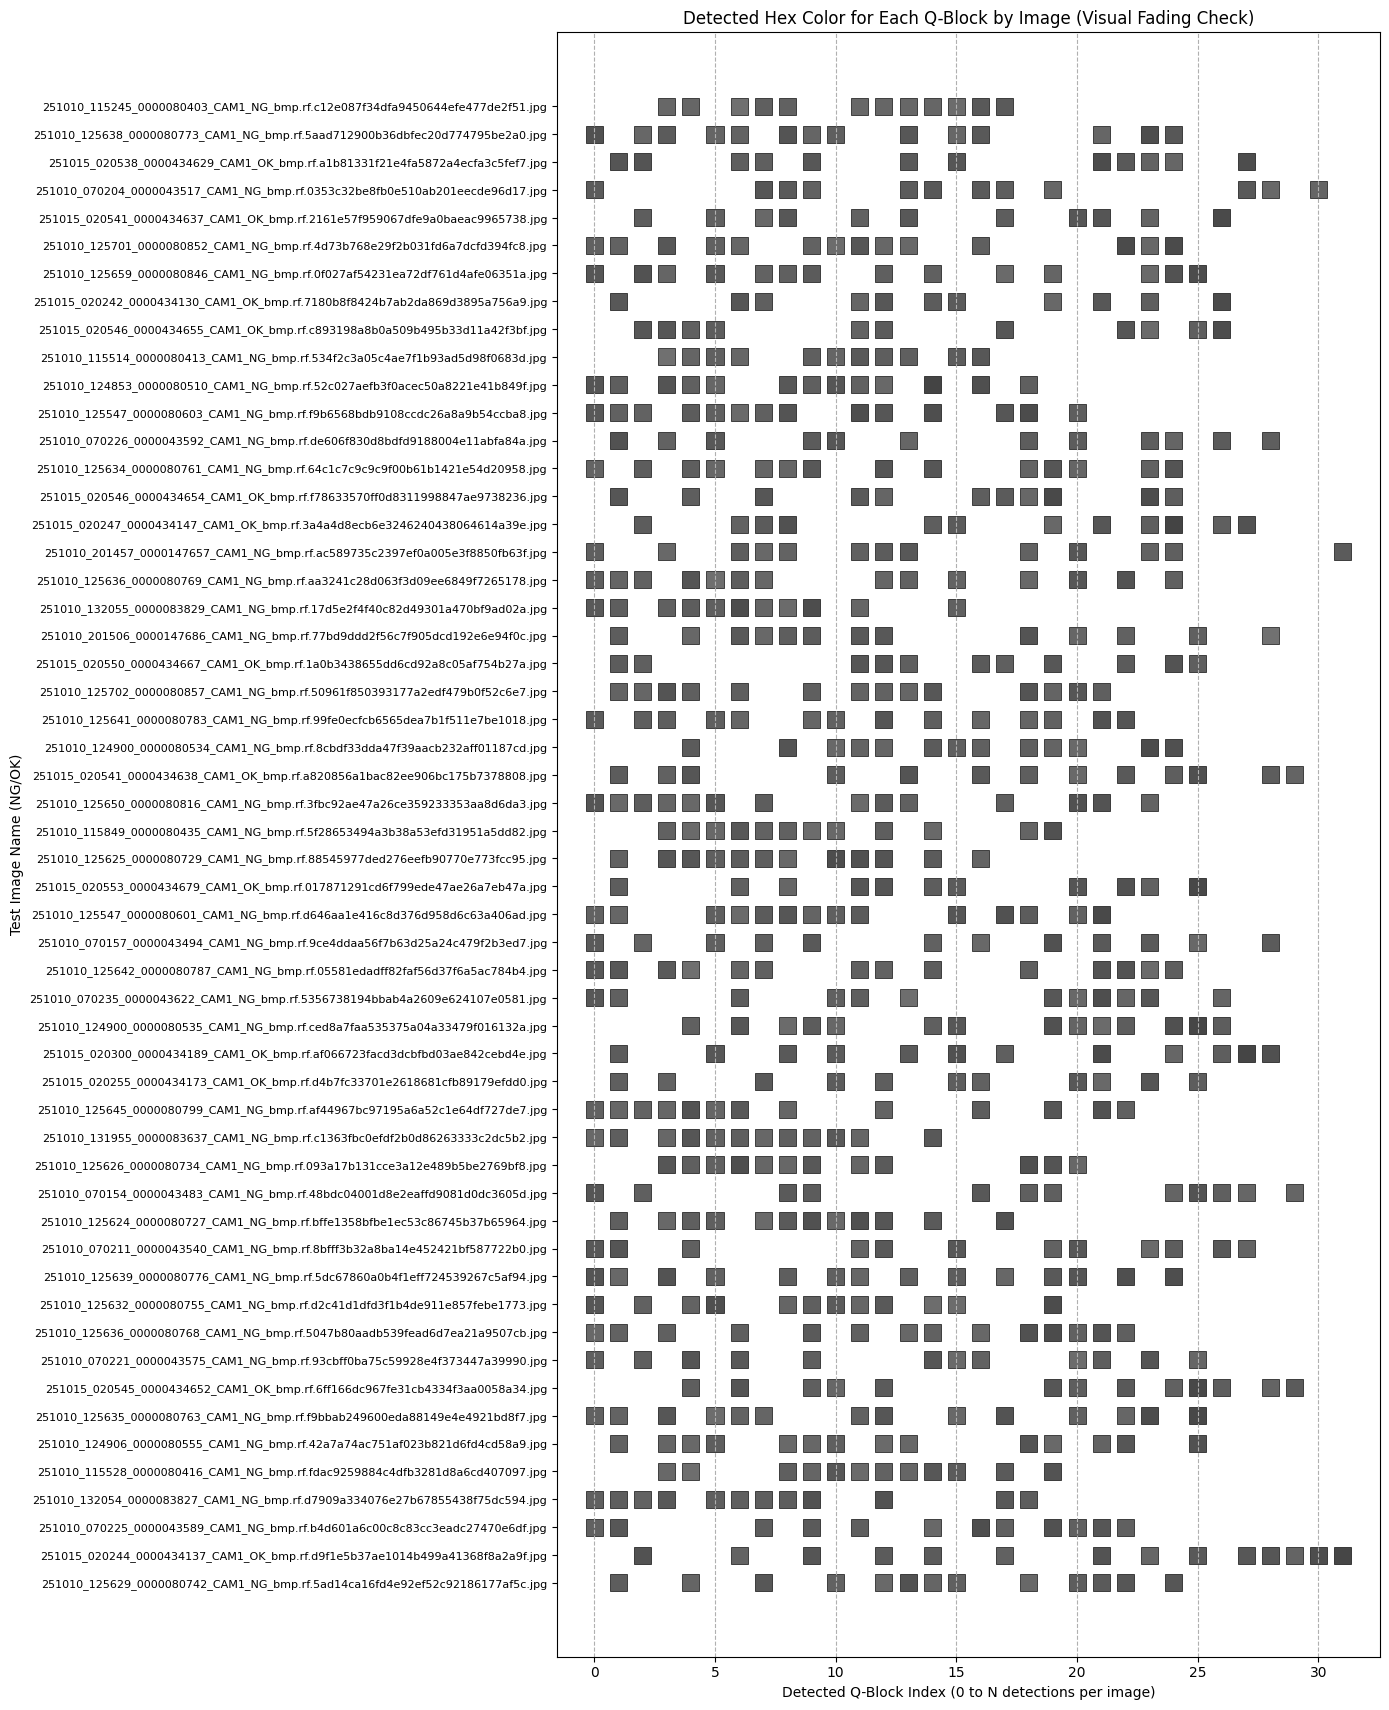

Color visualization for ALL detected blocks saved to: /content/test_results/all_qblock_color_scatter.png

--- Testing Complete! ---
Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'

--- Final QC Model Accuracy ---
Total Test Images Scored: 56
Correct Predictions:    28
QC Model Accuracy:        50.00%

--- Generating Color Visualization ---


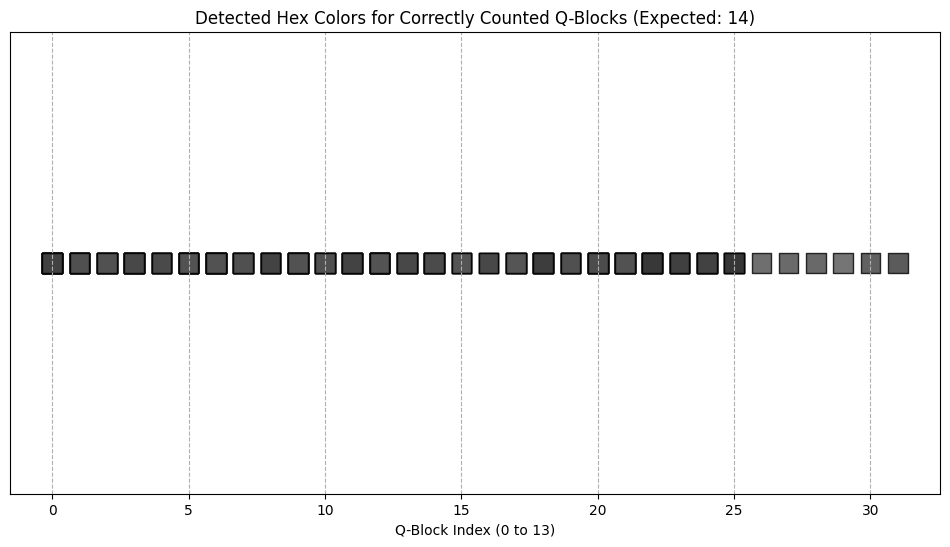

Color visualization saved to: /content/test_results/qblock_color_scatter.png


In [ ]:
import os
import glob
from ultralytics import YOLO
import yaml
import matplotlib.pyplot as plt
import pandas as pd

def run_full_pipeline():
    """
    Trains, validates, and tests a YOLOv8 model. Then, it classifies
    test images based on Q-block count and calculates the
    accuracy of this classification logic against file-name-based ground truth.
    """
    # config_path = 'datasets/eagle-eyes-4/data.yaml'

    # --- Pre-run Checks ---
    if not os.path.exists(config_path):
        print(f"Error: Configuration file not found at '{config_path}'")
        return

    # --- 1. Load a Pre-trained YOLOv8 Model ---
    print("Loading pre-trained YOLOv8n model...")
    model = YOLO('yolov8n.pt')

    # --- 2. Train the Model on Your Custom Data ---
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10,
        imgsz=640,
        batch=-1,
        name='yolov8n_qblock_detector'
    )

    print("--- Training complete! ---")

    # --- 3. Display Final Validation Metrics ---
    print("\nFinal Validation Metrics from Training:")
    print(f"  mAP50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall: {results.box.mr:.4f}")

    # --- 4. Load the Best Model for Inference ---
    print("\nLoading the best model for inference...")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')
    if not os.path.exists(best_model_path):
        print(f"Error: Could not find best model at '{best_model_path}'.")
        return

    best_model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    # --- 5. Test Model and Apply Business Logic ---
    print(f"\n--- Starting Test & QC Phase ---")

    with open(config_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    if 'test' not in data_yaml or not data_yaml['test']:
        print("Warning: 'test' path not found in your YAML file. Skipping test phase.")
        return

    base_dir = os.path.dirname(os.path.abspath(config_path))

    # Use os.path.join for cross-platform compatibility (fixing the previous string concatenation)
    test_img_dir = os.path.join(base_dir, 'test', 'images')

    print(f"BASE DIRECTORY:", base_dir)
    print(f"TEST IMAGE DIRECTORY:" ,test_img_dir)

    # --- FIX: ROBUST CLASS MAPPING LOGIC ---
    names_data = data_yaml['names']

    if isinstance(names_data, dict):
        # Case 1: 'names' is a dictionary (e.g., {0: 'qblock', 1: 'smallqblock'})
        # We invert it to get {'qblock': 0}
        class_names_to_ids = {v: k for k, v in names_data.items()}
    elif isinstance(names_data, list):
        # Case 2: 'names' is a list (e.g., ['qblock', 'smallqblock', 'clutter'])
        # The index (i) is the class ID.
        class_names_to_ids = {name: i for i, name in enumerate(names_data)}
    else:
        print("Error: 'names' field in data.yaml is neither a list nor a dictionary.")
        return
    # --- END FIX ---

    # 2. Get the specific ID for the 'qblock' class
    if 'qblock' not in class_names_to_ids:
        print("Error: The class 'qblock' was not found in the dataset configuration. Check your YAML 'names' list/dict.")
        return

    QBLOCK_CLASS_ID = class_names_to_ids['qblock']
    print(f"Counting only detections with Class ID: {QBLOCK_CLASS_ID} ('qblock')")

    if not os.path.exists(test_img_dir):
        print(f"Error: Test directory specified in YAML does not exist: '{test_img_dir}'")
        return

    image_extensions = ['*.bmp', '*.jpg', '*.jpeg', '*.png']
    test_images = []
    for ext in image_extensions:
        test_images.extend(glob.glob(os.path.join(test_img_dir, ext)))

    if not test_images:
        print(f"Warning: No images found in the test directory '{test_img_dir}'. Skipping test phase.")
    else:
        print(f"Found {len(test_images)} images to test from path specified in YAML.")

        # --- QC LOGIC & ACCURACY CALCULATION ADDED HERE ---

        # 1. DEFINE YOUR "GOOD" STATE:
        EXPECTED_QBLOCK_COUNT = 14
        print(f"Applying QC Rule: Image is 'GOOD' if Q-block count is exactly {EXPECTED_QBLOCK_COUNT}.")

        # 2. Run prediction. (Code here remains the same)
        predict_results = best_model.predict(
            source=test_images,
            save=True,
            project="test_results",
            name="predictions_with_qc_accuracy",
            exist_ok=True,
            conf=0.5 # Set a confidence threshold
        )

        print("\n--- QC Classification Results ---")

        correct_predictions = 0
        total_images_processed = 0

        # 3. Loop through results and classify each image
        # for image_path, result in zip(test_images, predict_results):
        #     image_name = os.path.basename(image_path)

        #     # --- Determine Ground Truth (from filename) ---
        #     ground_truth = "UNKNOWN"
        #     if "_OK" in image_name.upper():
        #         ground_truth = "GOOD"
        #     elif "_NG" in image_name.upper():
        #         ground_truth = "NOT_GOOD"

        #     # --- MODIFIED: Determine Model Prediction (ONLY COUNT 'qblock') ---

        #     # Get the tensor of class IDs for all detected boxes
        #     class_ids = result.boxes.cls.cpu() # Move to CPU if necessary for numpy/tensor ops

        #     # Count only the instances where the class ID matches the 'qblock' ID
        #     qblock_count = (class_ids == QBLOCK_CLASS_ID).sum().item()

        #     # Use the filtered count for the QC logic
        #     num_detections = qblock_count
        #     model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

        #     # --- Score the Prediction ---
        #     if ground_truth == "UNKNOWN":
        #         print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
        #         continue

        #     total_images_processed += 1

        #     if model_prediction == ground_truth:
        #         correct_predictions += 1
        #         status = "[CORRECT]"
        #     else:
        #         status = "[INCORRECT]"

        #     print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")
        all_color_analysis = []

        for image_path, result in zip(test_images, predict_results):
            image_name = os.path.basename(image_path)

        #     # --- START NEW COLOR EXTRACTION LOGIC ---

            # Load the image using OpenCV
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not load image {image_path}")
                continue

            qblock_colors = []

            # Iterate over all detections in the image
            for box in result.boxes:
                # Check if the class is the main Q-block class
                class_id = int(box.cls.cpu().item())
                if class_id == QBLOCK_CLASS_ID:

                    # 1. Get bounding box coordinates (xyxy format: [x1, y1, x2, y2])
                    # Note: We convert to int for OpenCV slicing
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    # 2. Crop the Region of Interest (ROI)
                    roi = img[y1:y2, x1:x2]

                    # Skip if the bounding box is invalid/empty
                    if roi.size == 0:
                        continue

                    # 3. Calculate the average color (B, G, R order in OpenCV)
                    avg_color_bgr = np.mean(roi, axis=(0, 1))

                    # 4. Convert BGR to RGB and format as Hex
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    qblock_colors.append((hex_color, (r, g, b), (x1, y1, x2, y2)))



            # --- Determine Ground Truth (from filename) ---
            # ... (existing ground truth logic) ...
            ground_truth = "UNKNOWN"
            if "_OK" in image_name.upper():
                ground_truth = "GOOD"
            elif "_NG" in image_name.upper():
                ground_truth = "NOT_GOOD"

            # --- Determine Model Prediction (using the filtered count) ---
            num_detections = len(qblock_colors) # Now use the count of Q-blocks found above
            model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

            # --- Score the Prediction ---
            if ground_truth == "UNKNOWN":
                print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
                continue

            total_images_processed += 1

            if model_prediction == ground_truth:
                correct_predictions += 1
                status = "[CORRECT]"
            else:
                status = "[INCORRECT]"

            print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")

            qblock_colors = []

    # Iterate over all detections in the image
            for i, box in enumerate(result.boxes): # i is the block index (0 to N)
                class_id = int(box.cls.cpu().item())

                if class_id == QBLOCK_CLASS_ID:
                    # ... (omitted: coordinate extraction) ...
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    roi = img[y1:y2, x1:x2]
                    if roi.size == 0:
                        continue

                    avg_color_bgr = np.mean(roi, axis=(0, 1))
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    # --- CAPTURE DATA IN A DICT ---
                    color_data = {
                        'image_name': image_name,
                        'block_index': i,
                        'hex_color': hex_color,
                        'r': r,
                        'g': g,
                        'b': b,
                        'ground_truth': ground_truth,
                        'model_prediction': model_prediction
                    }
                    all_color_analysis.append(color_data)

        print("\n--- Generating Color Visualization for ALL Q-Blocks ---")

        if all_color_analysis:
            # Convert the list of dictionaries to a Pandas DataFrame
            df = pd.DataFrame(all_color_analysis)

            # --- Create a single plot showing all Q-blocks and their colors ---

            # Calculate figure height dynamically based on the number of unique images
            num_images = len(df['image_name'].unique())
            fig_height = max(6, num_images * 0.3 + 1)

            plt.figure(figsize=(14, fig_height))

            # Scatter plot: X is the block index, Y is the image name, Color is the hex code
            plt.scatter(
                df['block_index'],
                df['image_name'],
                c=df['hex_color'],
                s=150, # Size of the color marker (swatch size)
                alpha=0.9,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black',
                linewidth=0.5
            )

            plt.xlabel("Detected Q-Block Index (0 to N detections per image)")
            plt.ylabel("Test Image Name (NG/OK)")
            plt.title(f"Detected Hex Color for Each Q-Block by Image (Visual Fading Check)")
            plt.grid(axis='x', linestyle='--')

            # Adjust Y-axis labels for readability if image names are long
            plt.gca().tick_params(axis='y', labelsize=8)

            # Save the visualization
            results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
            plot_path = os.path.join(results_directory, 'all_qblock_color_scatter.png')
            plt.tight_layout() # Ensures everything fits in the figure area
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization for ALL detected blocks saved to: {plot_path}")
        else:
            print("\nNo Q-blocks were detected to generate a visualization.")
                # --- END NEW COLOR EXTRACTION LOGIC ---
            # --- PRINT THE COLOR RESULTS ---
            if qblock_colors:
                print(f"    -> Detected Colors (First 3):")
                for hex_c, rgb_c, coords in qblock_colors[:3]:
                    print(f"       Box Coords: {coords} | Avg Hex Color: {hex_c}")
            elif num_detections > 0:
                 print("    -> Error: Q-blocks detected but color calculation failed.")

        print("\n--- Testing Complete! ---")
        print("Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'")

        # --- 4. Calculate and Print Final Accuracy ---
        if total_images_processed > 0:
            accuracy = (correct_predictions / total_images_processed) * 100
            print("\n--- Final QC Model Accuracy ---")
            print(f"Total Test Images Scored: {total_images_processed}")
            print(f"Correct Predictions:    {correct_predictions}")
            print(f"QC Model Accuracy:        {accuracy:.2f}%")
        else:
            print("\nNo scorable images (containing '_OK' or '_NG') were found in the test set.")
    print("\n--- Generating Color Visualization ---")

    if all_color_analysis:
        df = pd.DataFrame(all_color_analysis)

        # --- Create a single plot showing all Q-blocks and their colors ---

        # Filter only images where the QC count was correct (i.e., num_detections = 14)
        # This prevents clutter from images with 0 or too many detections.
        df_correct_count = df.groupby('image_name').filter(
            lambda x: len(x) == EXPECTED_QBLOCK_COUNT
        )

        if not df_correct_count.empty:
            plt.figure(figsize=(12, 6))

            # We plot the block index vs. a constant value (0) just to place them.
            # The key information is the color and the image they belong to.
            plt.scatter(
                df_correct_count['block_index'],
                [0] * len(df_correct_count),
                c=df_correct_count['hex_color'],
                s=200, # Size of the color marker
                alpha=0.8,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black'
            )

            plt.yticks([]) # Hide the Y-axis as it's just a placeholder
            plt.xlabel("Q-Block Index (0 to 13)")
            plt.title(f"Detected Hex Colors for Correctly Counted Q-Blocks (Expected: {EXPECTED_QBLOCK_COUNT})")
            plt.grid(axis='x', linestyle='--')

            # Optional: Add the average hex color for all blocks in the image
            # avg_color = df_correct_count.groupby('image_name')[['r', 'g', 'b']].mean().apply(
            #     lambda x: f'#{int(x.r):02x}{int(x.g):02x}{int(x.b):02x}', axis=1
            # )

            # Save the visualization
            plot_path = os.path.join(results_directory, 'qblock_color_scatter.png')
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization saved to: {plot_path}")
        else:
            print("No images found with the exact expected Q-block count (14) to generate a visualization.")

if __name__ == '__main__':
    run_full_pipeline()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Assume all_color_analysis (list of dictionaries) is populated from the loop

def plot_color_gradation(all_color_analysis, results_directory):
    """Generates a bar plot sorted by the Red channel to visualize color fading."""
    if not all_color_analysis:
        print("No Q-blocks were detected to generate a gradation plot.")
        return

    df_all = pd.DataFrame(all_color_analysis)

    # Sort by the Red component. A higher R value often indicates a brighter/faded appearance.
    df_sorted = df_all.sort_values(by='r', ascending=True).reset_index(drop=True)

    plt.figure(figsize=(15, 4))

    # Create the bar plot where the width of each bar is 1 to make a continuous strip
    plt.bar(
        x=df_sorted.index,
        height=1,
        color=df_sorted['hex_color'],
        width=1,
        edgecolor='black',
        linewidth=0.2
    )

    plt.title(f"Q-Block Color Gradation: Sorted by Red Channel (Total Blocks: {len(df_sorted)})")
    plt.xlabel("Q-Block Index (Sorted from Least Red to Most Red)")

    # Clean up the y-axis
    plt.yticks([])
    plt.ylim(0, 1)

    # Add notes to indicate the direction of fading
    plt.text(len(df_sorted) * 0.01, 0.5, 'Least Faded (Lower R)',
             verticalalignment='center', color='black', fontsize=10)
    plt.text(len(df_sorted) * 0.99, 0.5, 'Most Faded (Higher R)',
             verticalalignment='center', color='black', fontsize=10, ha='right')

    gradation_path = os.path.join(results_directory, 'qblock_color_gradation.png')
    plt.tight_layout()
    plt.savefig(gradation_path)
    # The key line to print the plot in the notebook:
    plt.show()

    print(f"Color gradation plot saved to: {gradation_path}")

# You would call this function after the prediction loop completes

def plot_rgb_diagnostic(all_color_analysis, results_directory):
    """Generates a line plot showing R, G, B values for all blocks to spot numerical outliers."""
    if not all_color_analysis:
        return

    df_all = pd.DataFrame(all_color_analysis).reset_index(names='block_id')

    plt.figure(figsize=(15, 6))

    # Plot each color channel as a separate line
    plt.plot(df_all['block_id'], df_all['r'], label='Red Channel (R)', marker='.', linestyle='-')
    plt.plot(df_all['block_id'], df_all['g'], label='Green Channel (G)', marker='.', linestyle='-')
    plt.plot(df_all['block_id'], df_all['b'], label='Blue Channel (B)', marker='.', linestyle='-')

    plt.title("RGB Channel Values Across All Detected Q-Blocks")
    plt.xlabel("Detected Q-Block Index (Combined Across All Images)")
    plt.ylabel("Color Channel Value (0 - 255)")
    plt.legend()
    plt.grid(True, axis='y', linestyle='--')

    # Highlight the range of values for better inspection
    # min_val = df_all[['r', 'g', 'b']].min().min() - 5
    # max_val = df_all[['r', 'g', 'b']].max().max() + 5
    # plt.ylim(max(0, min_val), min(255, max_val))

    # Find the absolute min and max values across all R, G, B columns
    min_val = df_all[['r', 'g', 'b']].min().min()
    max_val = df_all[['r', 'g', 'b']].max().max()

    # Set the Y-limits to be only 2 units below the minimum and 2 units above the maximum
    plt.ylim(max(0, min_val - 2), min(255, max_val + 2))
    # This hyper-zoomed range will force the three lines to separate slightly if any difference exists.


    diagnostic_path = os.path.join(results_directory, 'rgb_diagnostic_plot.png')
    plt.tight_layout()
    plt.savefig(diagnostic_path)
    # Display the plot in the notebook
    plt.show()

    print(f"RGB diagnostic plot saved to: {diagnostic_path}")

# You would call this function after the prediction loop completes
# plot_rgb_diagnostic(all_color_analysis, results_directory)


Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-18/data.yaml
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_qblock_detector8, 

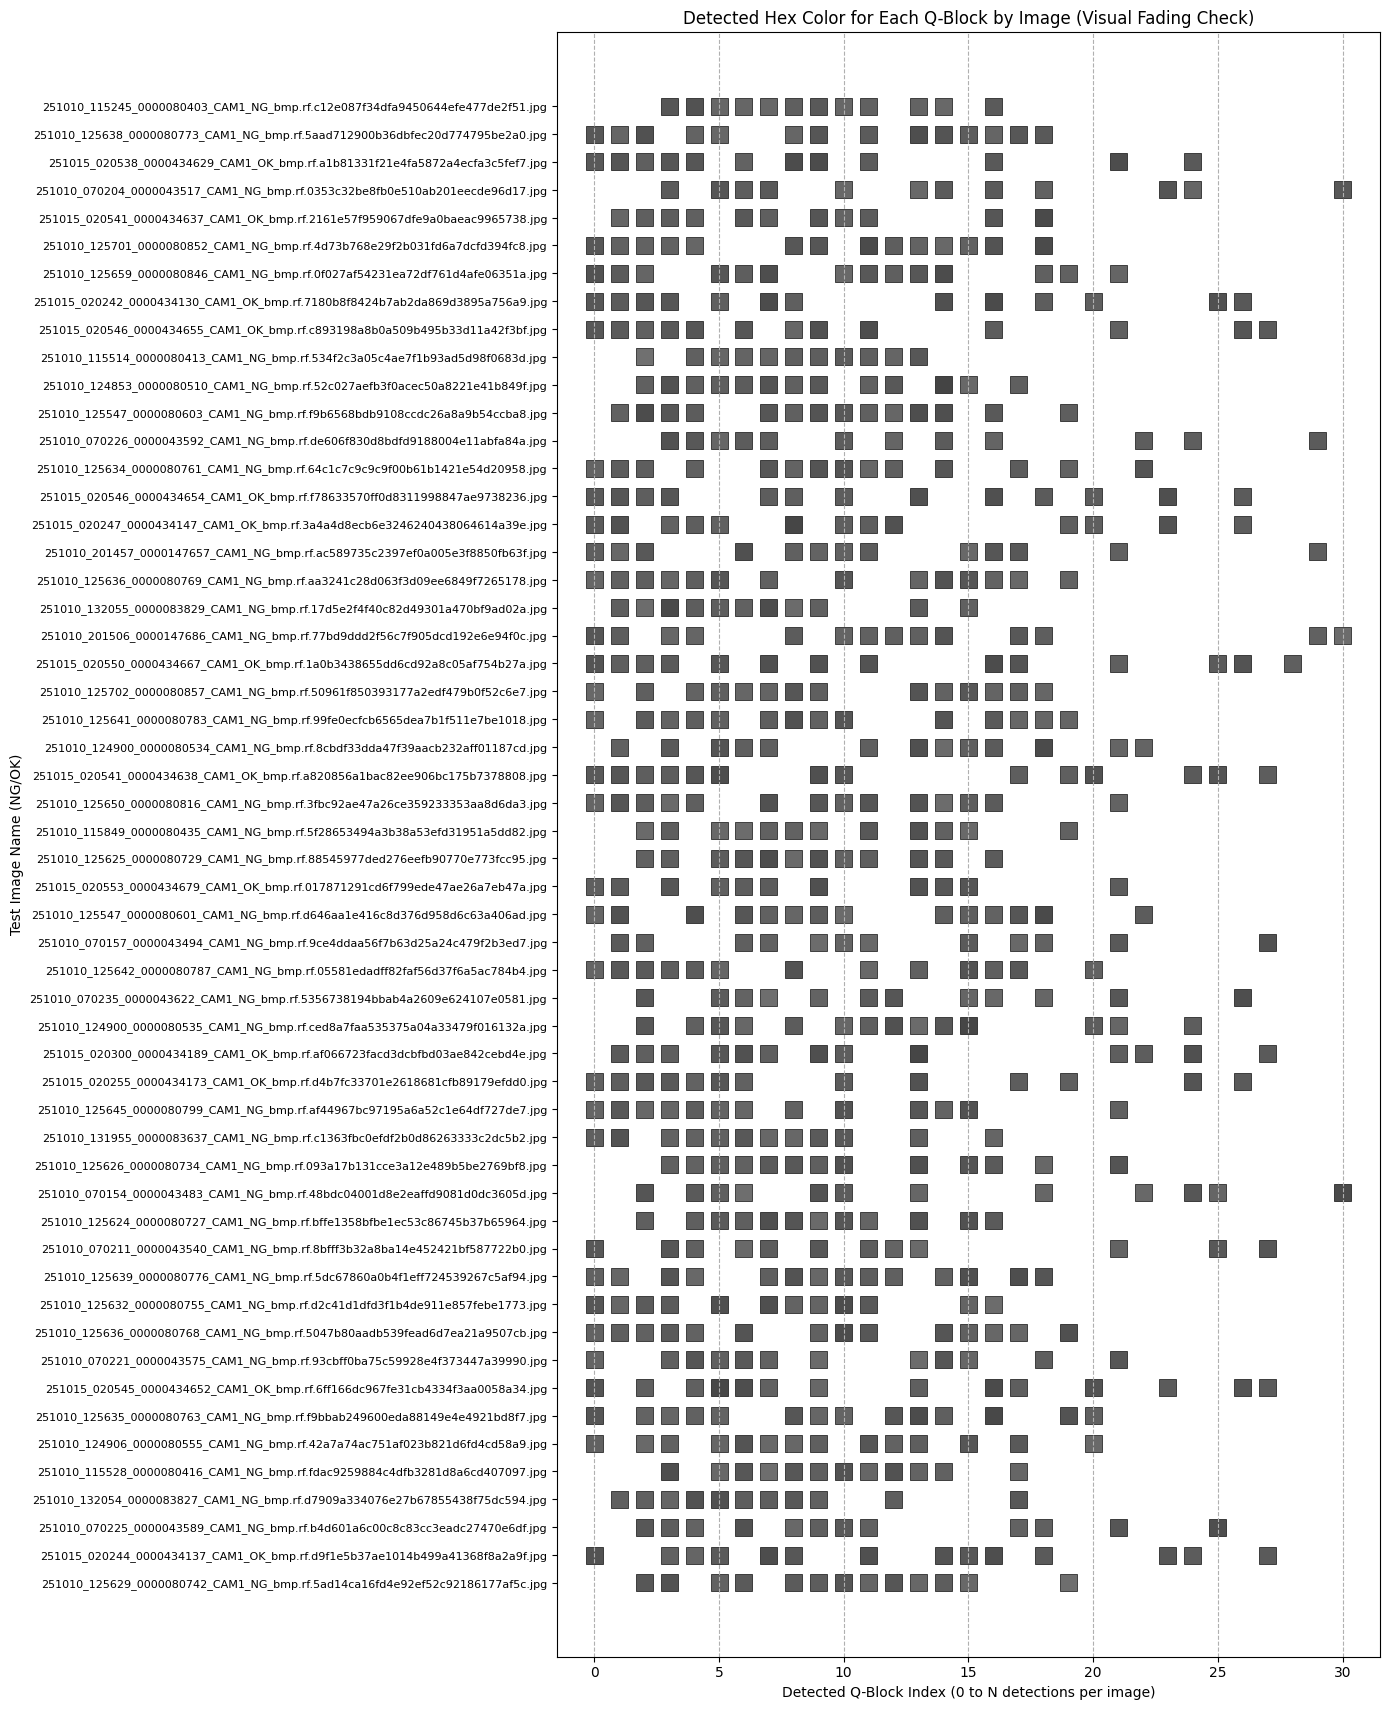

Color visualization for ALL detected blocks saved to: /content/test_results/all_qblock_color_scatter.png

--- Testing Complete! ---
Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'

--- Final QC Model Accuracy ---
Total Test Images Scored: 56
Correct Predictions:    31
QC Model Accuracy:        55.36%

--- Generating Color Visualization ---


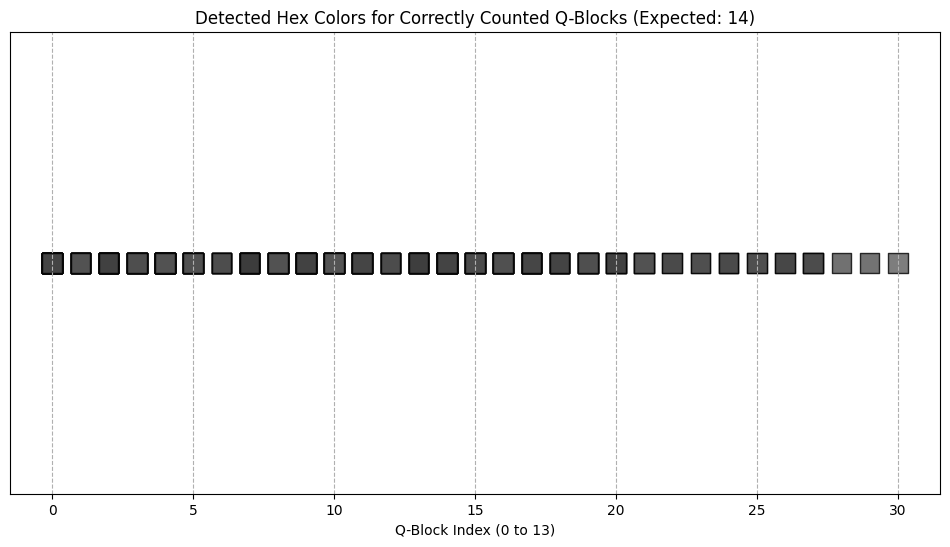

Color visualization saved to: /content/test_results/qblock_color_scatter.png

--- Generating Color Gradation Plot for Fading Check ---


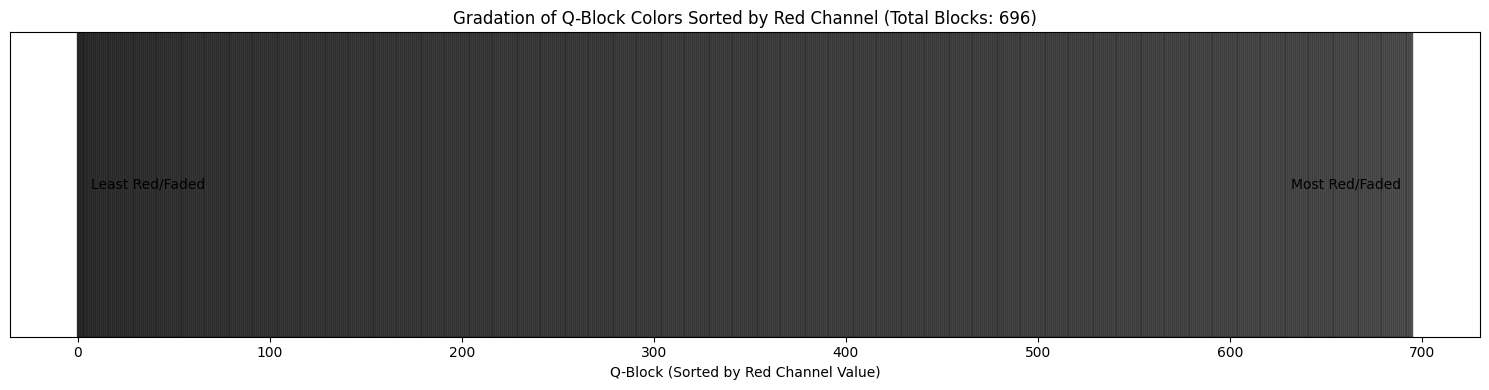

Color gradation plot saved to: /content/test_results/qblock_color_gradation.png
RGB Diagnostics plot


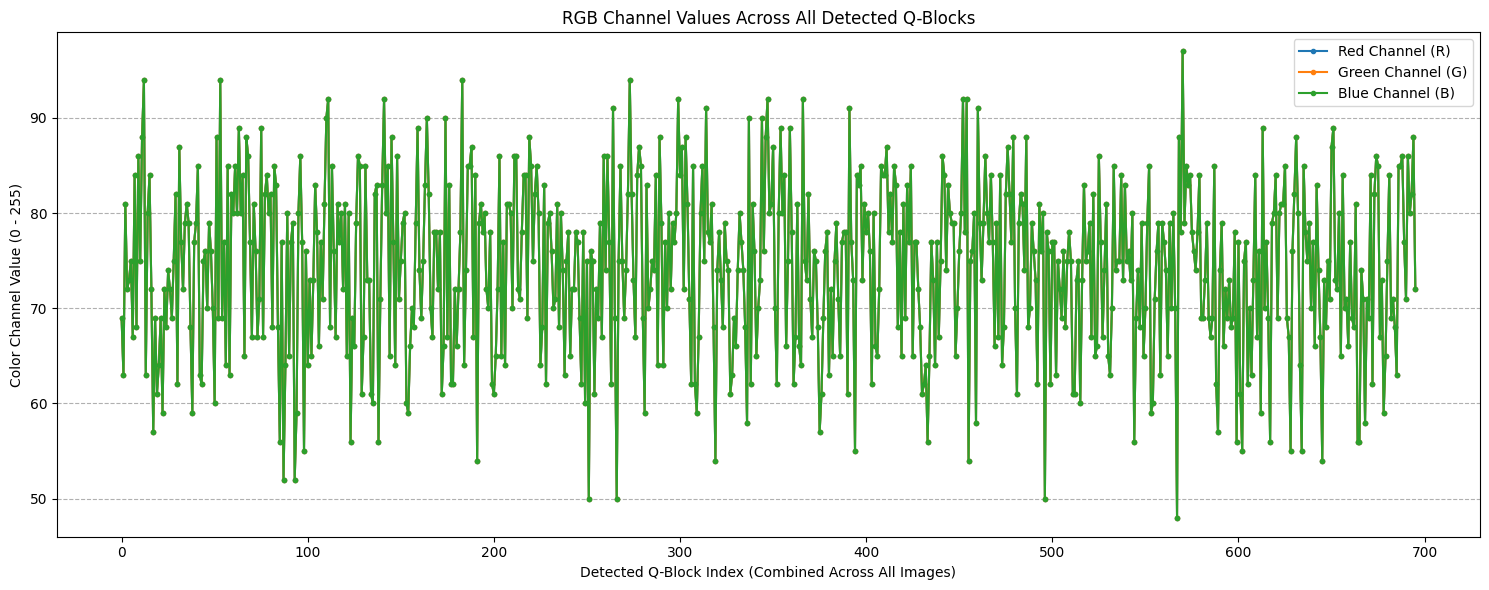

RGB diagnostic plot saved to: /content/test_results/rgb_diagnostic_plot.png


In [ ]:
import os
import glob
from ultralytics import YOLO
import yaml
import matplotlib.pyplot as plt
import pandas as pd

def run_full_pipeline():
    """
    Trains, validates, and tests a YOLOv8 model. Then, it classifies
    test images based on Q-block count and calculates the
    accuracy of this classification logic against file-name-based ground truth.
    """
    # config_path = 'datasets/eagle-eyes-4/data.yaml'

    # --- Pre-run Checks ---
    if not os.path.exists(config_path):
        print(f"Error: Configuration file not found at '{config_path}'")
        return

    # --- 1. Load a Pre-trained YOLOv8 Model ---
    print("Loading pre-trained YOLOv8n model...")
    model = YOLO('yolov8n.pt')

    # --- 2. Train the Model on Your Custom Data ---
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10,
        imgsz=640,
        batch=-1,
        name='yolov8n_qblock_detector'
    )

    print("--- Training complete! ---")

    # --- 3. Display Final Validation Metrics ---
    print("\nFinal Validation Metrics from Training:")
    print(f"  mAP50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall: {results.box.mr:.4f}")

    # --- 4. Load the Best Model for Inference ---
    print("\nLoading the best model for inference...")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')
    if not os.path.exists(best_model_path):
        print(f"Error: Could not find best model at '{best_model_path}'.")
        return

    best_model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    # --- 5. Test Model and Apply Business Logic ---
    print(f"\n--- Starting Test & QC Phase ---")

    with open(config_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    if 'test' not in data_yaml or not data_yaml['test']:
        print("Warning: 'test' path not found in your YAML file. Skipping test phase.")
        return

    base_dir = os.path.dirname(os.path.abspath(config_path))

    # Use os.path.join for cross-platform compatibility (fixing the previous string concatenation)
    test_img_dir = os.path.join(base_dir, 'test', 'images')

    print(f"BASE DIRECTORY:", base_dir)
    print(f"TEST IMAGE DIRECTORY:" ,test_img_dir)

    # --- FIX: ROBUST CLASS MAPPING LOGIC ---
    names_data = data_yaml['names']

    if isinstance(names_data, dict):
        # Case 1: 'names' is a dictionary (e.g., {0: 'qblock', 1: 'smallqblock'})
        # We invert it to get {'qblock': 0}
        class_names_to_ids = {v: k for k, v in names_data.items()}
    elif isinstance(names_data, list):
        # Case 2: 'names' is a list (e.g., ['qblock', 'smallqblock', 'clutter'])
        # The index (i) is the class ID.
        class_names_to_ids = {name: i for i, name in enumerate(names_data)}
    else:
        print("Error: 'names' field in data.yaml is neither a list nor a dictionary.")
        return
    # --- END FIX ---

    # 2. Get the specific ID for the 'qblock' class
    if 'qblock' not in class_names_to_ids:
        print("Error: The class 'qblock' was not found in the dataset configuration. Check your YAML 'names' list/dict.")
        return

    QBLOCK_CLASS_ID = class_names_to_ids['qblock']
    print(f"Counting only detections with Class ID: {QBLOCK_CLASS_ID} ('qblock')")

    if not os.path.exists(test_img_dir):
        print(f"Error: Test directory specified in YAML does not exist: '{test_img_dir}'")
        return

    image_extensions = ['*.bmp', '*.jpg', '*.jpeg', '*.png']
    test_images = []
    for ext in image_extensions:
        test_images.extend(glob.glob(os.path.join(test_img_dir, ext)))

    if not test_images:
        print(f"Warning: No images found in the test directory '{test_img_dir}'. Skipping test phase.")
    else:
        print(f"Found {len(test_images)} images to test from path specified in YAML.")

        # --- QC LOGIC & ACCURACY CALCULATION ADDED HERE ---

        # 1. DEFINE YOUR "GOOD" STATE:
        EXPECTED_QBLOCK_COUNT = 14
        print(f"Applying QC Rule: Image is 'GOOD' if Q-block count is exactly {EXPECTED_QBLOCK_COUNT}.")

        # 2. Run prediction. (Code here remains the same)
        predict_results = best_model.predict(
            source=test_images,
            save=True,
            project="test_results",
            name="predictions_with_qc_accuracy",
            exist_ok=True,
            conf=0.5 # Set a confidence threshold
        )

        print("\n--- QC Classification Results ---")

        correct_predictions = 0
        total_images_processed = 0

        # 3. Loop through results and classify each image
        # for image_path, result in zip(test_images, predict_results):
        #     image_name = os.path.basename(image_path)

        #     # --- Determine Ground Truth (from filename) ---
        #     ground_truth = "UNKNOWN"
        #     if "_OK" in image_name.upper():
        #         ground_truth = "GOOD"
        #     elif "_NG" in image_name.upper():
        #         ground_truth = "NOT_GOOD"

        #     # --- MODIFIED: Determine Model Prediction (ONLY COUNT 'qblock') ---

        #     # Get the tensor of class IDs for all detected boxes
        #     class_ids = result.boxes.cls.cpu() # Move to CPU if necessary for numpy/tensor ops

        #     # Count only the instances where the class ID matches the 'qblock' ID
        #     qblock_count = (class_ids == QBLOCK_CLASS_ID).sum().item()

        #     # Use the filtered count for the QC logic
        #     num_detections = qblock_count
        #     model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

        #     # --- Score the Prediction ---
        #     if ground_truth == "UNKNOWN":
        #         print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
        #         continue

        #     total_images_processed += 1

        #     if model_prediction == ground_truth:
        #         correct_predictions += 1
        #         status = "[CORRECT]"
        #     else:
        #         status = "[INCORRECT]"

        #     print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")
        all_color_analysis = []

        for image_path, result in zip(test_images, predict_results):
            image_name = os.path.basename(image_path)

        #     # --- START NEW COLOR EXTRACTION LOGIC ---

            # Load the image using OpenCV
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not load image {image_path}")
                continue

            qblock_colors = []

            # Iterate over all detections in the image
            for box in result.boxes:
                # Check if the class is the main Q-block class
                class_id = int(box.cls.cpu().item())
                if class_id == QBLOCK_CLASS_ID:

                    # 1. Get bounding box coordinates (xyxy format: [x1, y1, x2, y2])
                    # Note: We convert to int for OpenCV slicing
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    # 2. Crop the Region of Interest (ROI)
                    roi = img[y1:y2, x1:x2]

                    # Skip if the bounding box is invalid/empty
                    if roi.size == 0:
                        continue

                    # 3. Calculate the average color (B, G, R order in OpenCV)
                    avg_color_bgr = np.mean(roi, axis=(0, 1))

                    # 4. Convert BGR to RGB and format as Hex
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    qblock_colors.append((hex_color, (r, g, b), (x1, y1, x2, y2)))



            # --- Determine Ground Truth (from filename) ---
            # ... (existing ground truth logic) ...
            ground_truth = "UNKNOWN"
            if "_OK" in image_name.upper():
                ground_truth = "GOOD"
            elif "_NG" in image_name.upper():
                ground_truth = "NOT_GOOD"

            # --- Determine Model Prediction (using the filtered count) ---
            num_detections = len(qblock_colors) # Now use the count of Q-blocks found above
            model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

            # --- Score the Prediction ---
            if ground_truth == "UNKNOWN":
                print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
                continue

            total_images_processed += 1

            if model_prediction == ground_truth:
                correct_predictions += 1
                status = "[CORRECT]"
            else:
                status = "[INCORRECT]"

            print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")

            qblock_colors = []

    # Iterate over all detections in the image
            for i, box in enumerate(result.boxes): # i is the block index (0 to N)
                class_id = int(box.cls.cpu().item())

                if class_id == QBLOCK_CLASS_ID:
                    # ... (omitted: coordinate extraction) ...
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    roi = img[y1:y2, x1:x2]
                    if roi.size == 0:
                        continue

                    avg_color_bgr = np.mean(roi, axis=(0, 1))
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    # --- CAPTURE DATA IN A DICT ---
                    color_data = {
                        'image_name': image_name,
                        'block_index': i,
                        'hex_color': hex_color,
                        'r': r,
                        'g': g,
                        'b': b,
                        'ground_truth': ground_truth,
                        'model_prediction': model_prediction
                    }
                    all_color_analysis.append(color_data)

        print("\n--- Generating Color Visualization for ALL Q-Blocks ---")

        if all_color_analysis:
            # Convert the list of dictionaries to a Pandas DataFrame
            df = pd.DataFrame(all_color_analysis)

            # --- Create a single plot showing all Q-blocks and their colors ---

            # Calculate figure height dynamically based on the number of unique images
            num_images = len(df['image_name'].unique())
            fig_height = max(6, num_images * 0.3 + 1)

            plt.figure(figsize=(14, fig_height))

            # Scatter plot: X is the block index, Y is the image name, Color is the hex code
            plt.scatter(
                df['block_index'],
                df['image_name'],
                c=df['hex_color'],
                s=150, # Size of the color marker (swatch size)
                alpha=0.9,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black',
                linewidth=0.5
            )

            plt.xlabel("Detected Q-Block Index (0 to N detections per image)")
            plt.ylabel("Test Image Name (NG/OK)")
            plt.title(f"Detected Hex Color for Each Q-Block by Image (Visual Fading Check)")
            plt.grid(axis='x', linestyle='--')

            # Adjust Y-axis labels for readability if image names are long
            plt.gca().tick_params(axis='y', labelsize=8)

            # Save the visualization
            results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
            plot_path = os.path.join(results_directory, 'all_qblock_color_scatter.png')
            plt.tight_layout() # Ensures everything fits in the figure area
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization for ALL detected blocks saved to: {plot_path}")
        else:
            print("\nNo Q-blocks were detected to generate a visualization.")
                # --- END NEW COLOR EXTRACTION LOGIC ---
            # --- PRINT THE COLOR RESULTS ---
            if qblock_colors:
                print(f"    -> Detected Colors (First 3):")
                for hex_c, rgb_c, coords in qblock_colors[:3]:
                    print(f"       Box Coords: {coords} | Avg Hex Color: {hex_c}")
            elif num_detections > 0:
                 print("    -> Error: Q-blocks detected but color calculation failed.")

        print("\n--- Testing Complete! ---")
        print("Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'")

        # --- 4. Calculate and Print Final Accuracy ---
        if total_images_processed > 0:
            accuracy = (correct_predictions / total_images_processed) * 100
            print("\n--- Final QC Model Accuracy ---")
            print(f"Total Test Images Scored: {total_images_processed}")
            print(f"Correct Predictions:    {correct_predictions}")
            print(f"QC Model Accuracy:        {accuracy:.2f}%")
        else:
            print("\nNo scorable images (containing '_OK' or '_NG') were found in the test set.")
    print("\n--- Generating Color Visualization ---")

    if all_color_analysis:
        df = pd.DataFrame(all_color_analysis)

        # --- Create a single plot showing all Q-blocks and their colors ---

        # Filter only images where the QC count was correct (i.e., num_detections = 14)
        # This prevents clutter from images with 0 or too many detections.
        df_correct_count = df.groupby('image_name').filter(
            lambda x: len(x) == EXPECTED_QBLOCK_COUNT
        )

        if not df_correct_count.empty:
            plt.figure(figsize=(12, 6))

            # We plot the block index vs. a constant value (0) just to place them.
            # The key information is the color and the image they belong to.
            plt.scatter(
                df_correct_count['block_index'],
                [0] * len(df_correct_count),
                c=df_correct_count['hex_color'],
                s=200, # Size of the color marker
                alpha=0.8,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black'
            )

            plt.yticks([]) # Hide the Y-axis as it's just a placeholder
            plt.xlabel("Q-Block Index (0 to 13)")
            plt.title(f"Detected Hex Colors for Correctly Counted Q-Blocks (Expected: {EXPECTED_QBLOCK_COUNT})")
            plt.grid(axis='x', linestyle='--')

            # Optional: Add the average hex color for all blocks in the image
            # avg_color = df_correct_count.groupby('image_name')[['r', 'g', 'b']].mean().apply(
            #     lambda x: f'#{int(x.r):02x}{int(x.g):02x}{int(x.b):02x}', axis=1
            # )

            # Save the visualization
            plot_path = os.path.join(results_directory, 'qblock_color_scatter.png')
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization saved to: {plot_path}")
        else:
            print("No images found with the exact expected Q-block count (14) to generate a visualization.")
    print("\n--- Generating Color Gradation Plot for Fading Check ---")

    if all_color_analysis:
        df_all = pd.DataFrame(all_color_analysis)

        # Calculate the average color component to sort by.
        # Using 'r' is common, as fading often results in a higher R or overall brightness.
        # You could also use 'b' (if the blocks are blue) or 'r+g+b' for overall brightness.

        # Sort the entire dataset by the Red component (ascending = least red to most red/faded)
        df_sorted = df_all.sort_values(by='r', ascending=True).reset_index(drop=True)

        plt.figure(figsize=(15, 4))

        # Create a bar plot using the hex color for the bar color
        plt.bar(
            x=df_sorted.index,
            height=1, # Constant height for visibility
            color=df_sorted['hex_color'],
            width=1, # Width of 1 to create solid adjacent bars
            edgecolor='black',
            linewidth=0.2
        )

        plt.title(f"Gradation of Q-Block Colors Sorted by Red Channel (Total Blocks: {len(df_sorted)})")
        plt.xlabel("Q-Block (Sorted by Red Channel Value)")

        # Remove y-axis ticks and labels as they are meaningless here
        plt.yticks([])

        # Set y-limits to just show the bar
        plt.ylim(0, 1)

        # Add a note on the plot to identify the direction of fading
        plt.text(len(df_sorted) * 0.01, 0.5, 'Least Red/Faded',
                verticalalignment='center', color='black', fontsize=10)
        plt.text(len(df_sorted) * 0.99, 0.5, 'Most Red/Faded',
                verticalalignment='center', color='black', fontsize=10, ha='right')

        # Save and display the plot
        results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
        gradation_path = os.path.join(results_directory, 'qblock_color_gradation.png')
        plt.tight_layout()
        plt.savefig(gradation_path)
        plt.show() # Display the plot in the notebook

        print(f"Color gradation plot saved to: {gradation_path}")

    else:
        print("\nNo Q-blocks were detected to generate a gradation plot.")

  # print("Color gradation plot")
  # plot_color_gradation(all_color_analysis, results_directory)
    print("RGB Diagnostics plot")
    plot_rgb_diagnostic(all_color_analysis, results_directory)

# You would call this function after the prediction loop completes
# plot_color_gradation(all_color_analysis, results_directory)
if __name__ == '__main__':
    run_full_pipeline()


### Experiment with faded q block images

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
version = project.version(23)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
import os
import cv2
import numpy as np

In [3]:

dataset_root_path = dataset.location
print(f"Automatically Detected Dataset Path: {dataset_root_path}")
print(f"Type of object: {type(dataset)}")

# You can now use this variable to build the config_path
# Assuming the Roboflow download structure (YOLOv8)
# The data.yaml file is typically one level up from the 'train' folder.
config_path = os.path.join(dataset_root_path, 'data.yaml')
print(f"YOLOv8 Config Path: {config_path}")

Automatically Detected Dataset Path: /content/eagle-eyes-23
Type of object: <class 'roboflow.core.dataset.Dataset'>
YOLOv8 Config Path: /content/eagle-eyes-23/data.yaml


In [4]:
%pip install protobuf==3.20.3 tensorboard ultralytics

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, f

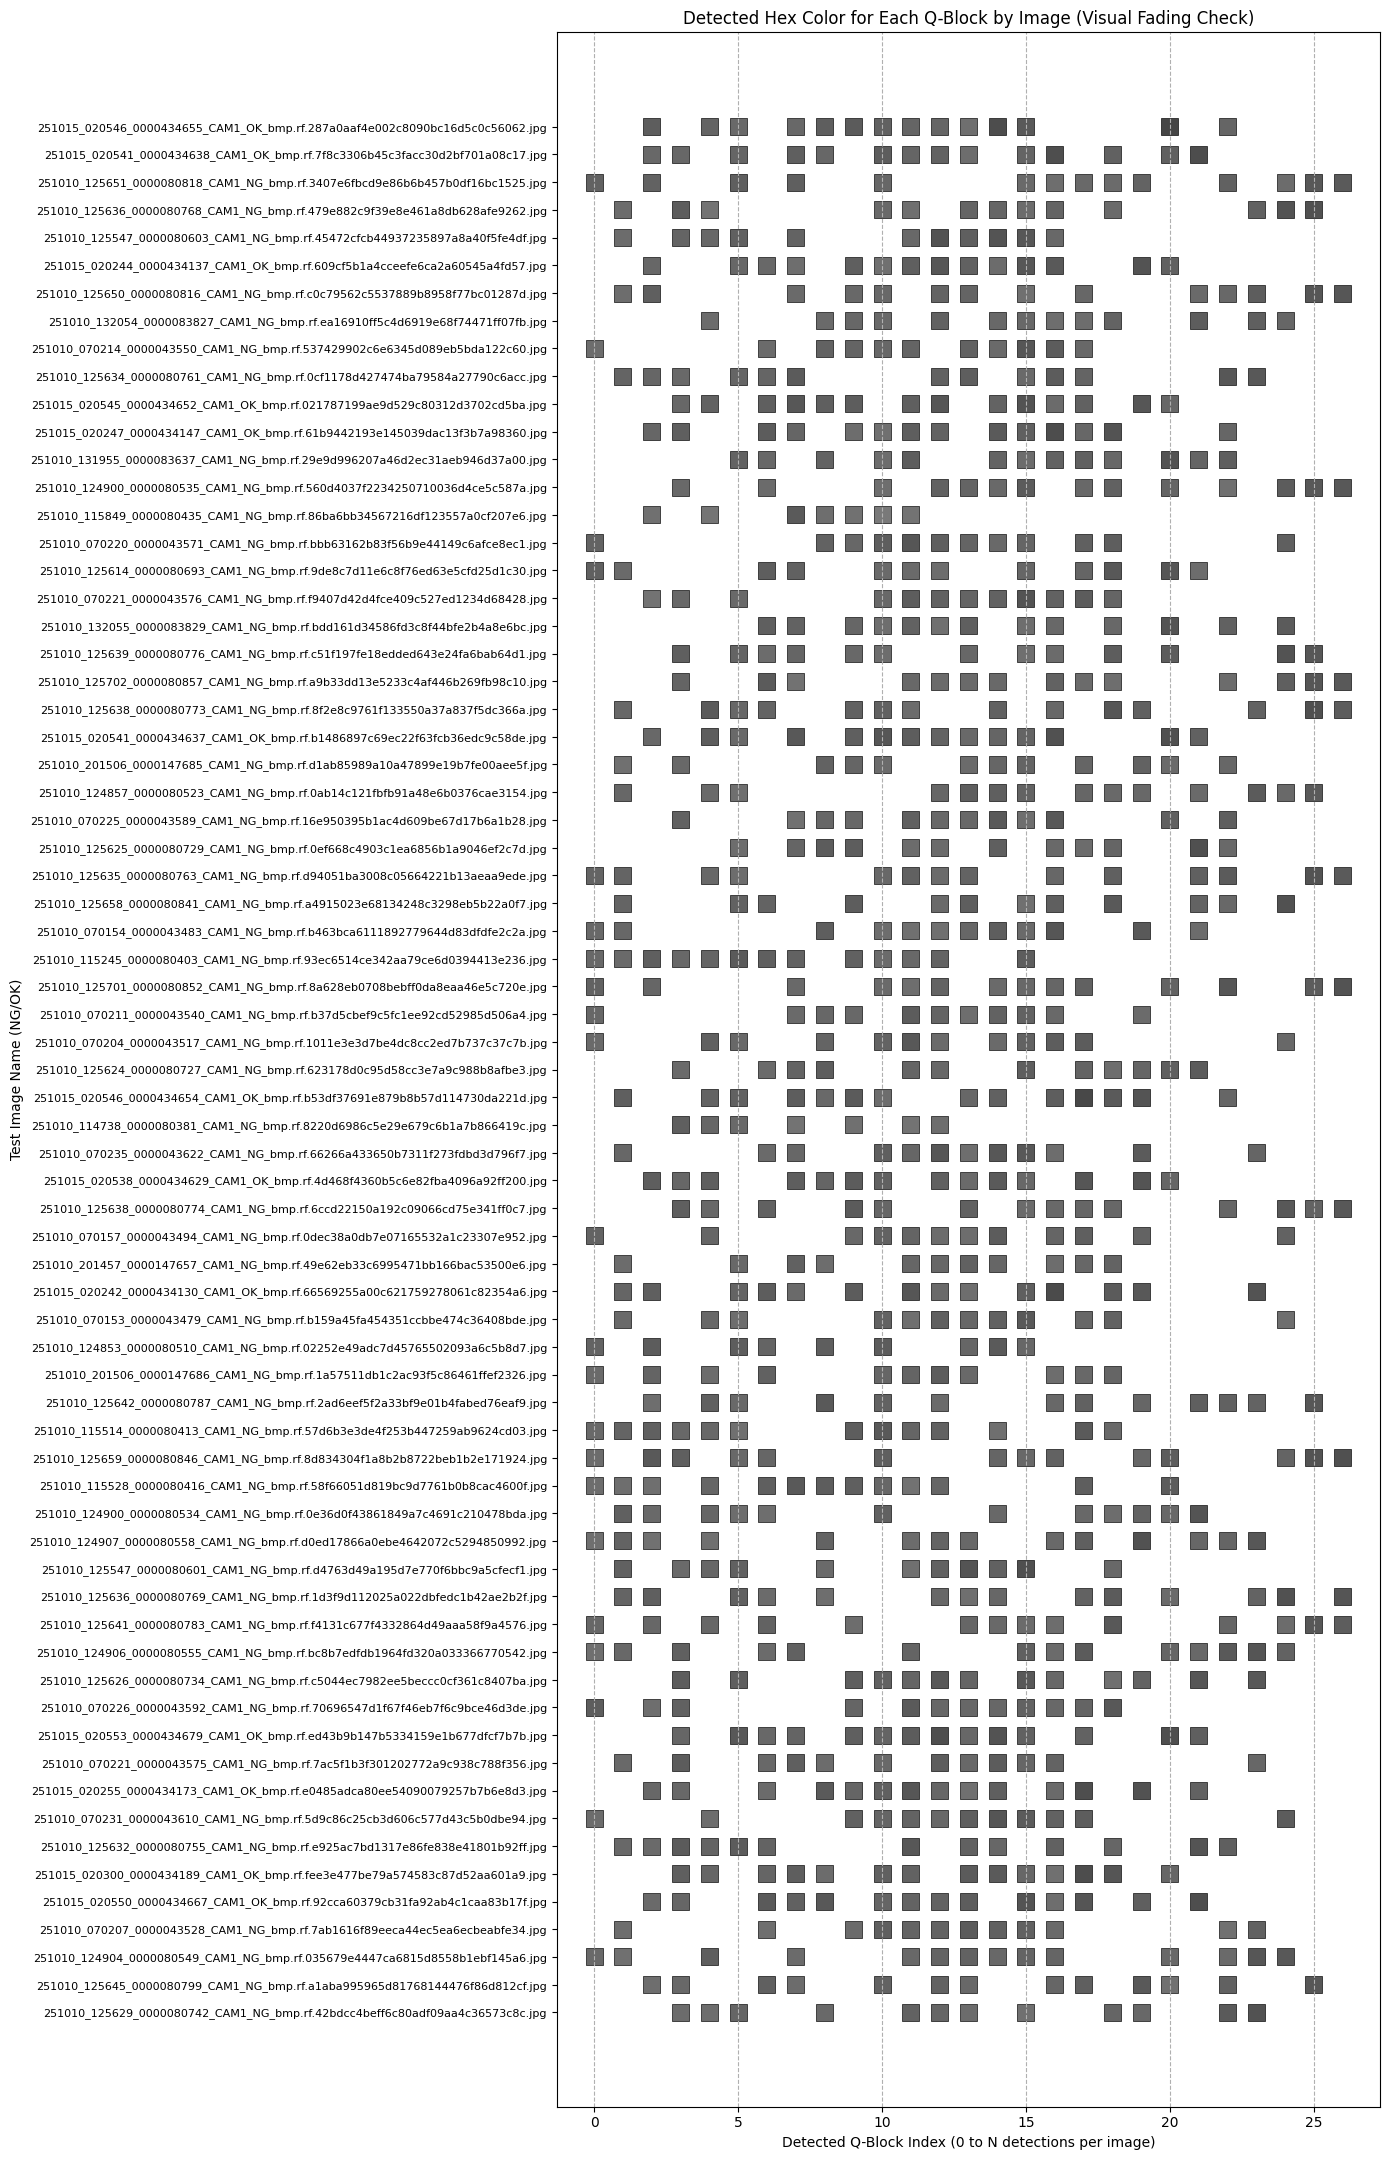

Color visualization for ALL detected blocks saved to: /content/test_results/all_qblock_color_scatter.png

--- Testing Complete! ---
Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'

--- Final QC Model Accuracy ---
Total Test Images Scored: 138
Correct Predictions:    123
QC Model Accuracy:        89.13%

--- Generating Color Visualization ---


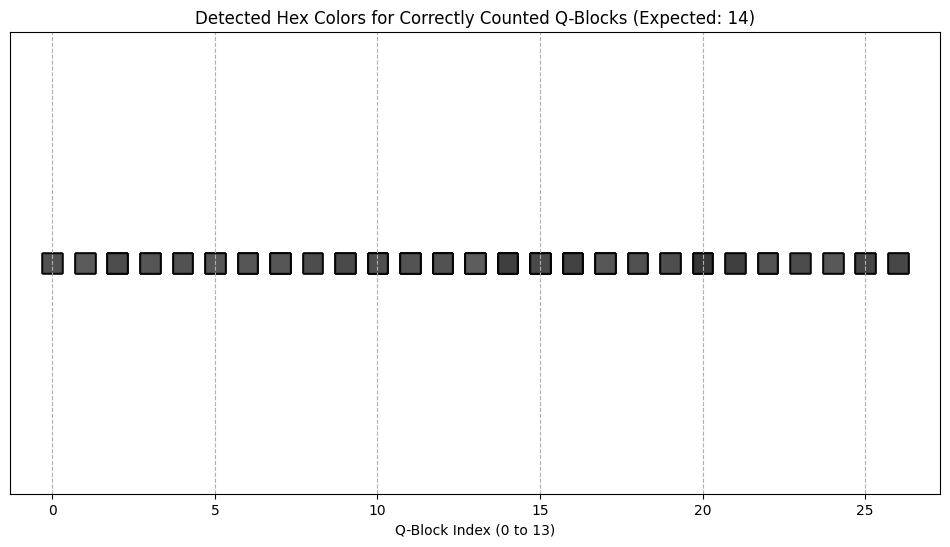

Color visualization saved to: /content/test_results/qblock_color_scatter.png


In [5]:
import os
import glob
from ultralytics import YOLO
import yaml
import matplotlib.pyplot as plt
import pandas as pd

def run_full_pipeline():
    """
    Trains, validates, and tests a YOLOv8 model. Then, it classifies
    test images based on Q-block count and calculates the
    accuracy of this classification logic against file-name-based ground truth.
    """
    # config_path = 'datasets/eagle-eyes-4/data.yaml'

    # --- Pre-run Checks ---
    if not os.path.exists(config_path):
        print(f"Error: Configuration file not found at '{config_path}'")
        return

    # --- 1. Load a Pre-trained YOLOv8 Model ---
    print("Loading pre-trained YOLOv8n model...")
    model = YOLO('yolov8n.pt')

    # --- 2. Train the Model on Your Custom Data ---
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10,
        imgsz=640,
        batch=-1,
        name='yolov8n_qblock_detector'
    )

    print("--- Training complete! ---")

    # --- 3. Display Final Validation Metrics ---
    print("\nFinal Validation Metrics from Training:")
    print(f"  mAP50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall: {results.box.mr:.4f}")

    # --- 4. Load the Best Model for Inference ---
    print("\nLoading the best model for inference...")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')
    if not os.path.exists(best_model_path):
        print(f"Error: Could not find best model at '{best_model_path}'.")
        return

    best_model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    # --- 5. Test Model and Apply Business Logic ---
    print(f"\n--- Starting Test & QC Phase ---")

    with open(config_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    if 'test' not in data_yaml or not data_yaml['test']:
        print("Warning: 'test' path not found in your YAML file. Skipping test phase.")
        return

    base_dir = os.path.dirname(os.path.abspath(config_path))

    # Use os.path.join for cross-platform compatibility (fixing the previous string concatenation)
    test_img_dir = os.path.join(base_dir, 'test', 'images')

    print(f"BASE DIRECTORY:", base_dir)
    print(f"TEST IMAGE DIRECTORY:" ,test_img_dir)

    # --- FIX: ROBUST CLASS MAPPING LOGIC ---
    names_data = data_yaml['names']

    if isinstance(names_data, dict):
        # Case 1: 'names' is a dictionary (e.g., {0: 'qblock', 1: 'smallqblock'})
        # We invert it to get {'qblock': 0}
        class_names_to_ids = {v: k for k, v in names_data.items()}
    elif isinstance(names_data, list):
        # Case 2: 'names' is a list (e.g., ['qblock', 'smallqblock', 'clutter'])
        # The index (i) is the class ID.
        class_names_to_ids = {name: i for i, name in enumerate(names_data)}
    else:
        print("Error: 'names' field in data.yaml is neither a list nor a dictionary.")
        return
    # --- END FIX ---

    # 2. Get the specific ID for the 'qblock' class
    if 'qblock' not in class_names_to_ids:
        print("Error: The class 'qblock' was not found in the dataset configuration. Check your YAML 'names' list/dict.")
        return

    QBLOCK_CLASS_ID = class_names_to_ids['qblock']
    print(f"Counting only detections with Class ID: {QBLOCK_CLASS_ID} ('qblock')")

    if not os.path.exists(test_img_dir):
        print(f"Error: Test directory specified in YAML does not exist: '{test_img_dir}'")
        return

    image_extensions = ['*.bmp', '*.jpg', '*.jpeg', '*.png']
    test_images = []
    for ext in image_extensions:
        test_images.extend(glob.glob(os.path.join(test_img_dir, ext)))

    if not test_images:
        print(f"Warning: No images found in the test directory '{test_img_dir}'. Skipping test phase.")
    else:
        print(f"Found {len(test_images)} images to test from path specified in YAML.")

        # --- QC LOGIC & ACCURACY CALCULATION ADDED HERE ---

        # 1. DEFINE YOUR "GOOD" STATE:
        EXPECTED_QBLOCK_COUNT = 14
        print(f"Applying QC Rule: Image is 'GOOD' if Q-block count is exactly {EXPECTED_QBLOCK_COUNT}.")

        # 2. Run prediction. (Code here remains the same)
        predict_results = best_model.predict(
            source=test_images,
            save=True,
            project="test_results",
            name="predictions_with_qc_accuracy",
            exist_ok=True,
            conf=0.5 # Set a confidence threshold
        )

        print("\n--- QC Classification Results ---")

        correct_predictions = 0
        total_images_processed = 0

        # 3. Loop through results and classify each image
        # for image_path, result in zip(test_images, predict_results):
        #     image_name = os.path.basename(image_path)

        #     # --- Determine Ground Truth (from filename) ---
        #     ground_truth = "UNKNOWN"
        #     if "_OK" in image_name.upper():
        #         ground_truth = "GOOD"
        #     elif "_NG" in image_name.upper():
        #         ground_truth = "NOT_GOOD"

        #     # --- MODIFIED: Determine Model Prediction (ONLY COUNT 'qblock') ---

        #     # Get the tensor of class IDs for all detected boxes
        #     class_ids = result.boxes.cls.cpu() # Move to CPU if necessary for numpy/tensor ops

        #     # Count only the instances where the class ID matches the 'qblock' ID
        #     qblock_count = (class_ids == QBLOCK_CLASS_ID).sum().item()

        #     # Use the filtered count for the QC logic
        #     num_detections = qblock_count
        #     model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

        #     # --- Score the Prediction ---
        #     if ground_truth == "UNKNOWN":
        #         print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
        #         continue

        #     total_images_processed += 1

        #     if model_prediction == ground_truth:
        #         correct_predictions += 1
        #         status = "[CORRECT]"
        #     else:
        #         status = "[INCORRECT]"

        #     print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")
        all_color_analysis = []

        for image_path, result in zip(test_images, predict_results):
            image_name = os.path.basename(image_path)

        #     # --- START NEW COLOR EXTRACTION LOGIC ---

            # Load the image using OpenCV
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not load image {image_path}")
                continue

            qblock_colors = []

            # Iterate over all detections in the image
            for box in result.boxes:
                # Check if the class is the main Q-block class
                class_id = int(box.cls.cpu().item())
                if class_id == QBLOCK_CLASS_ID:

                    # 1. Get bounding box coordinates (xyxy format: [x1, y1, x2, y2])
                    # Note: We convert to int for OpenCV slicing
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    # 2. Crop the Region of Interest (ROI)
                    roi = img[y1:y2, x1:x2]

                    # Skip if the bounding box is invalid/empty
                    if roi.size == 0:
                        continue

                    # 3. Calculate the average color (B, G, R order in OpenCV)
                    avg_color_bgr = np.mean(roi, axis=(0, 1))

                    # 4. Convert BGR to RGB and format as Hex
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    qblock_colors.append((hex_color, (r, g, b), (x1, y1, x2, y2)))



            # --- Determine Ground Truth (from filename) ---
            # ... (existing ground truth logic) ...
            ground_truth = "UNKNOWN"
            if "_OK" in image_name.upper():
                ground_truth = "GOOD"
            elif "_NG" in image_name.upper():
                ground_truth = "NOT_GOOD"

            # --- Determine Model Prediction (using the filtered count) ---
            num_detections = len(qblock_colors) # Now use the count of Q-blocks found above
            model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

            # --- Score the Prediction ---
            if ground_truth == "UNKNOWN":
                print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
                continue

            total_images_processed += 1

            if model_prediction == ground_truth:
                correct_predictions += 1
                status = "[CORRECT]"
            else:
                status = "[INCORRECT]"

            print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")

            qblock_colors = []

    # Iterate over all detections in the image
            for i, box in enumerate(result.boxes): # i is the block index (0 to N)
                class_id = int(box.cls.cpu().item())

                if class_id == QBLOCK_CLASS_ID:
                    # ... (omitted: coordinate extraction) ...
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    roi = img[y1:y2, x1:x2]
                    if roi.size == 0:
                        continue

                    avg_color_bgr = np.mean(roi, axis=(0, 1))
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    # --- CAPTURE DATA IN A DICT ---
                    color_data = {
                        'image_name': image_name,
                        'block_index': i,
                        'hex_color': hex_color,
                        'r': r,
                        'g': g,
                        'b': b,
                        'ground_truth': ground_truth,
                        'model_prediction': model_prediction
                    }
                    all_color_analysis.append(color_data)

        print("\n--- Generating Color Visualization for ALL Q-Blocks ---")

        if all_color_analysis:
            # Convert the list of dictionaries to a Pandas DataFrame
            df = pd.DataFrame(all_color_analysis)

            # --- Create a single plot showing all Q-blocks and their colors ---

            # Calculate figure height dynamically based on the number of unique images
            num_images = len(df['image_name'].unique())
            fig_height = max(6, num_images * 0.3 + 1)

            plt.figure(figsize=(14, fig_height))

            # Scatter plot: X is the block index, Y is the image name, Color is the hex code
            plt.scatter(
                df['block_index'],
                df['image_name'],
                c=df['hex_color'],
                s=150, # Size of the color marker (swatch size)
                alpha=0.9,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black',
                linewidth=0.5
            )

            plt.xlabel("Detected Q-Block Index (0 to N detections per image)")
            plt.ylabel("Test Image Name (NG/OK)")
            plt.title(f"Detected Hex Color for Each Q-Block by Image (Visual Fading Check)")
            plt.grid(axis='x', linestyle='--')

            # Adjust Y-axis labels for readability if image names are long
            plt.gca().tick_params(axis='y', labelsize=8)

            # Save the visualization
            results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
            plot_path = os.path.join(results_directory, 'all_qblock_color_scatter.png')
            plt.tight_layout() # Ensures everything fits in the figure area
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization for ALL detected blocks saved to: {plot_path}")
        else:
            print("\nNo Q-blocks were detected to generate a visualization.")
                # --- END NEW COLOR EXTRACTION LOGIC ---
            # --- PRINT THE COLOR RESULTS ---
            if qblock_colors:
                print(f"    -> Detected Colors (First 3):")
                for hex_c, rgb_c, coords in qblock_colors[:3]:
                    print(f"       Box Coords: {coords} | Avg Hex Color: {hex_c}")
            elif num_detections > 0:
                 print("    -> Error: Q-blocks detected but color calculation failed.")

        print("\n--- Testing Complete! ---")
        print("Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'")

        # --- 4. Calculate and Print Final Accuracy ---
        if total_images_processed > 0:
            accuracy = (correct_predictions / total_images_processed) * 100
            print("\n--- Final QC Model Accuracy ---")
            print(f"Total Test Images Scored: {total_images_processed}")
            print(f"Correct Predictions:    {correct_predictions}")
            print(f"QC Model Accuracy:        {accuracy:.2f}%")
        else:
            print("\nNo scorable images (containing '_OK' or '_NG') were found in the test set.")
    print("\n--- Generating Color Visualization ---")

    if all_color_analysis:
        df = pd.DataFrame(all_color_analysis)

        # --- Create a single plot showing all Q-blocks and their colors ---

        # Filter only images where the QC count was correct (i.e., num_detections = 14)
        # This prevents clutter from images with 0 or too many detections.
        df_correct_count = df.groupby('image_name').filter(
            lambda x: len(x) == EXPECTED_QBLOCK_COUNT
        )

        if not df_correct_count.empty:
            plt.figure(figsize=(12, 6))

            # We plot the block index vs. a constant value (0) just to place them.
            # The key information is the color and the image they belong to.
            plt.scatter(
                df_correct_count['block_index'],
                [0] * len(df_correct_count),
                c=df_correct_count['hex_color'],
                s=200, # Size of the color marker
                alpha=0.8,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black'
            )

            plt.yticks([]) # Hide the Y-axis as it's just a placeholder
            plt.xlabel("Q-Block Index (0 to 13)")
            plt.title(f"Detected Hex Colors for Correctly Counted Q-Blocks (Expected: {EXPECTED_QBLOCK_COUNT})")
            plt.grid(axis='x', linestyle='--')

            # Optional: Add the average hex color for all blocks in the image
            # avg_color = df_correct_count.groupby('image_name')[['r', 'g', 'b']].mean().apply(
            #     lambda x: f'#{int(x.r):02x}{int(x.g):02x}{int(x.b):02x}', axis=1
            # )

            # Save the visualization
            plot_path = os.path.join(results_directory, 'qblock_color_scatter.png')
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization saved to: {plot_path}")
        else:
            print("No images found with the exact expected Q-block count (14) to generate a visualization.")

if __name__ == '__main__':
    run_full_pipeline()


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
# Assume all_color_analysis (list of dictionaries) is populated from the loop

def plot_color_gradation(all_color_analysis, results_directory):
    """Generates a bar plot sorted by the Red channel to visualize color fading."""
    if not all_color_analysis:
        print("No Q-blocks were detected to generate a gradation plot.")
        return

    df_all = pd.DataFrame(all_color_analysis)

    # Sort by the Red component. A higher R value often indicates a brighter/faded appearance.
    df_sorted = df_all.sort_values(by='r', ascending=True).reset_index(drop=True)

    plt.figure(figsize=(15, 4))

    # Create the bar plot where the width of each bar is 1 to make a continuous strip
    plt.bar(
        x=df_sorted.index,
        height=1,
        color=df_sorted['hex_color'],
        width=1,
        edgecolor='black',
        linewidth=0.2
    )

    plt.title(f"Q-Block Color Gradation: Sorted by Red Channel (Total Blocks: {len(df_sorted)})")
    plt.xlabel("Q-Block Index (Sorted from Least Red to Most Red)")

    # Clean up the y-axis
    plt.yticks([])
    plt.ylim(0, 1)

    # Add notes to indicate the direction of fading
    plt.text(len(df_sorted) * 0.01, 0.5, 'Least Faded (Lower R)',
             verticalalignment='center', color='black', fontsize=10)
    plt.text(len(df_sorted) * 0.99, 0.5, 'Most Faded (Higher R)',
             verticalalignment='center', color='black', fontsize=10, ha='right')

    gradation_path = os.path.join(results_directory, 'qblock_color_gradation.png')
    plt.tight_layout()
    plt.savefig(gradation_path)
    # The key line to print the plot in the notebook:
    plt.show()

    print(f"Color gradation plot saved to: {gradation_path}")

# You would call this function after the prediction loop completes

def plot_rgb_diagnostic(all_color_analysis, results_directory):
    """Generates a line plot showing R, G, B values for all blocks to spot numerical outliers."""
    if not all_color_analysis:
        return

    df_all = pd.DataFrame(all_color_analysis).reset_index(names='block_id')

    plt.figure(figsize=(15, 6))

    # Plot each color channel as a separate line
    plt.plot(df_all['block_id'], df_all['r'], label='Red Channel (R)', marker='.', linestyle='-')
    plt.plot(df_all['block_id'], df_all['g'], label='Green Channel (G)', marker='.', linestyle='-')
    plt.plot(df_all['block_id'], df_all['b'], label='Blue Channel (B)', marker='.', linestyle='-')

    plt.title("RGB Channel Values Across All Detected Q-Blocks")
    plt.xlabel("Detected Q-Block Index (Combined Across All Images)")
    plt.ylabel("Color Channel Value (0 - 255)")
    plt.legend()
    plt.grid(True, axis='y', linestyle='--')

    # Highlight the range of values for better inspection
    # min_val = df_all[['r', 'g', 'b']].min().min() - 5
    # max_val = df_all[['r', 'g', 'b']].max().max() + 5
    # plt.ylim(max(0, min_val), min(255, max_val))

    # Find the absolute min and max values across all R, G, B columns
    min_val = df_all[['r', 'g', 'b']].min().min()
    max_val = df_all[['r', 'g', 'b']].max().max()

    # Set the Y-limits to be only 2 units below the minimum and 2 units above the maximum
    plt.ylim(max(0, min_val - 2), min(255, max_val + 2))
    # This hyper-zoomed range will force the three lines to separate slightly if any difference exists.


    diagnostic_path = os.path.join(results_directory, 'rgb_diagnostic_plot.png')
    plt.tight_layout()
    plt.savefig(diagnostic_path)
    # Display the plot in the notebook
    plt.show()

    print(f"RGB diagnostic plot saved to: {diagnostic_path}")

# You would call this function after the prediction loop completes
# plot_rgb_diagnostic(all_color_analysis, results_directory)


Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_qblock_detector2, 

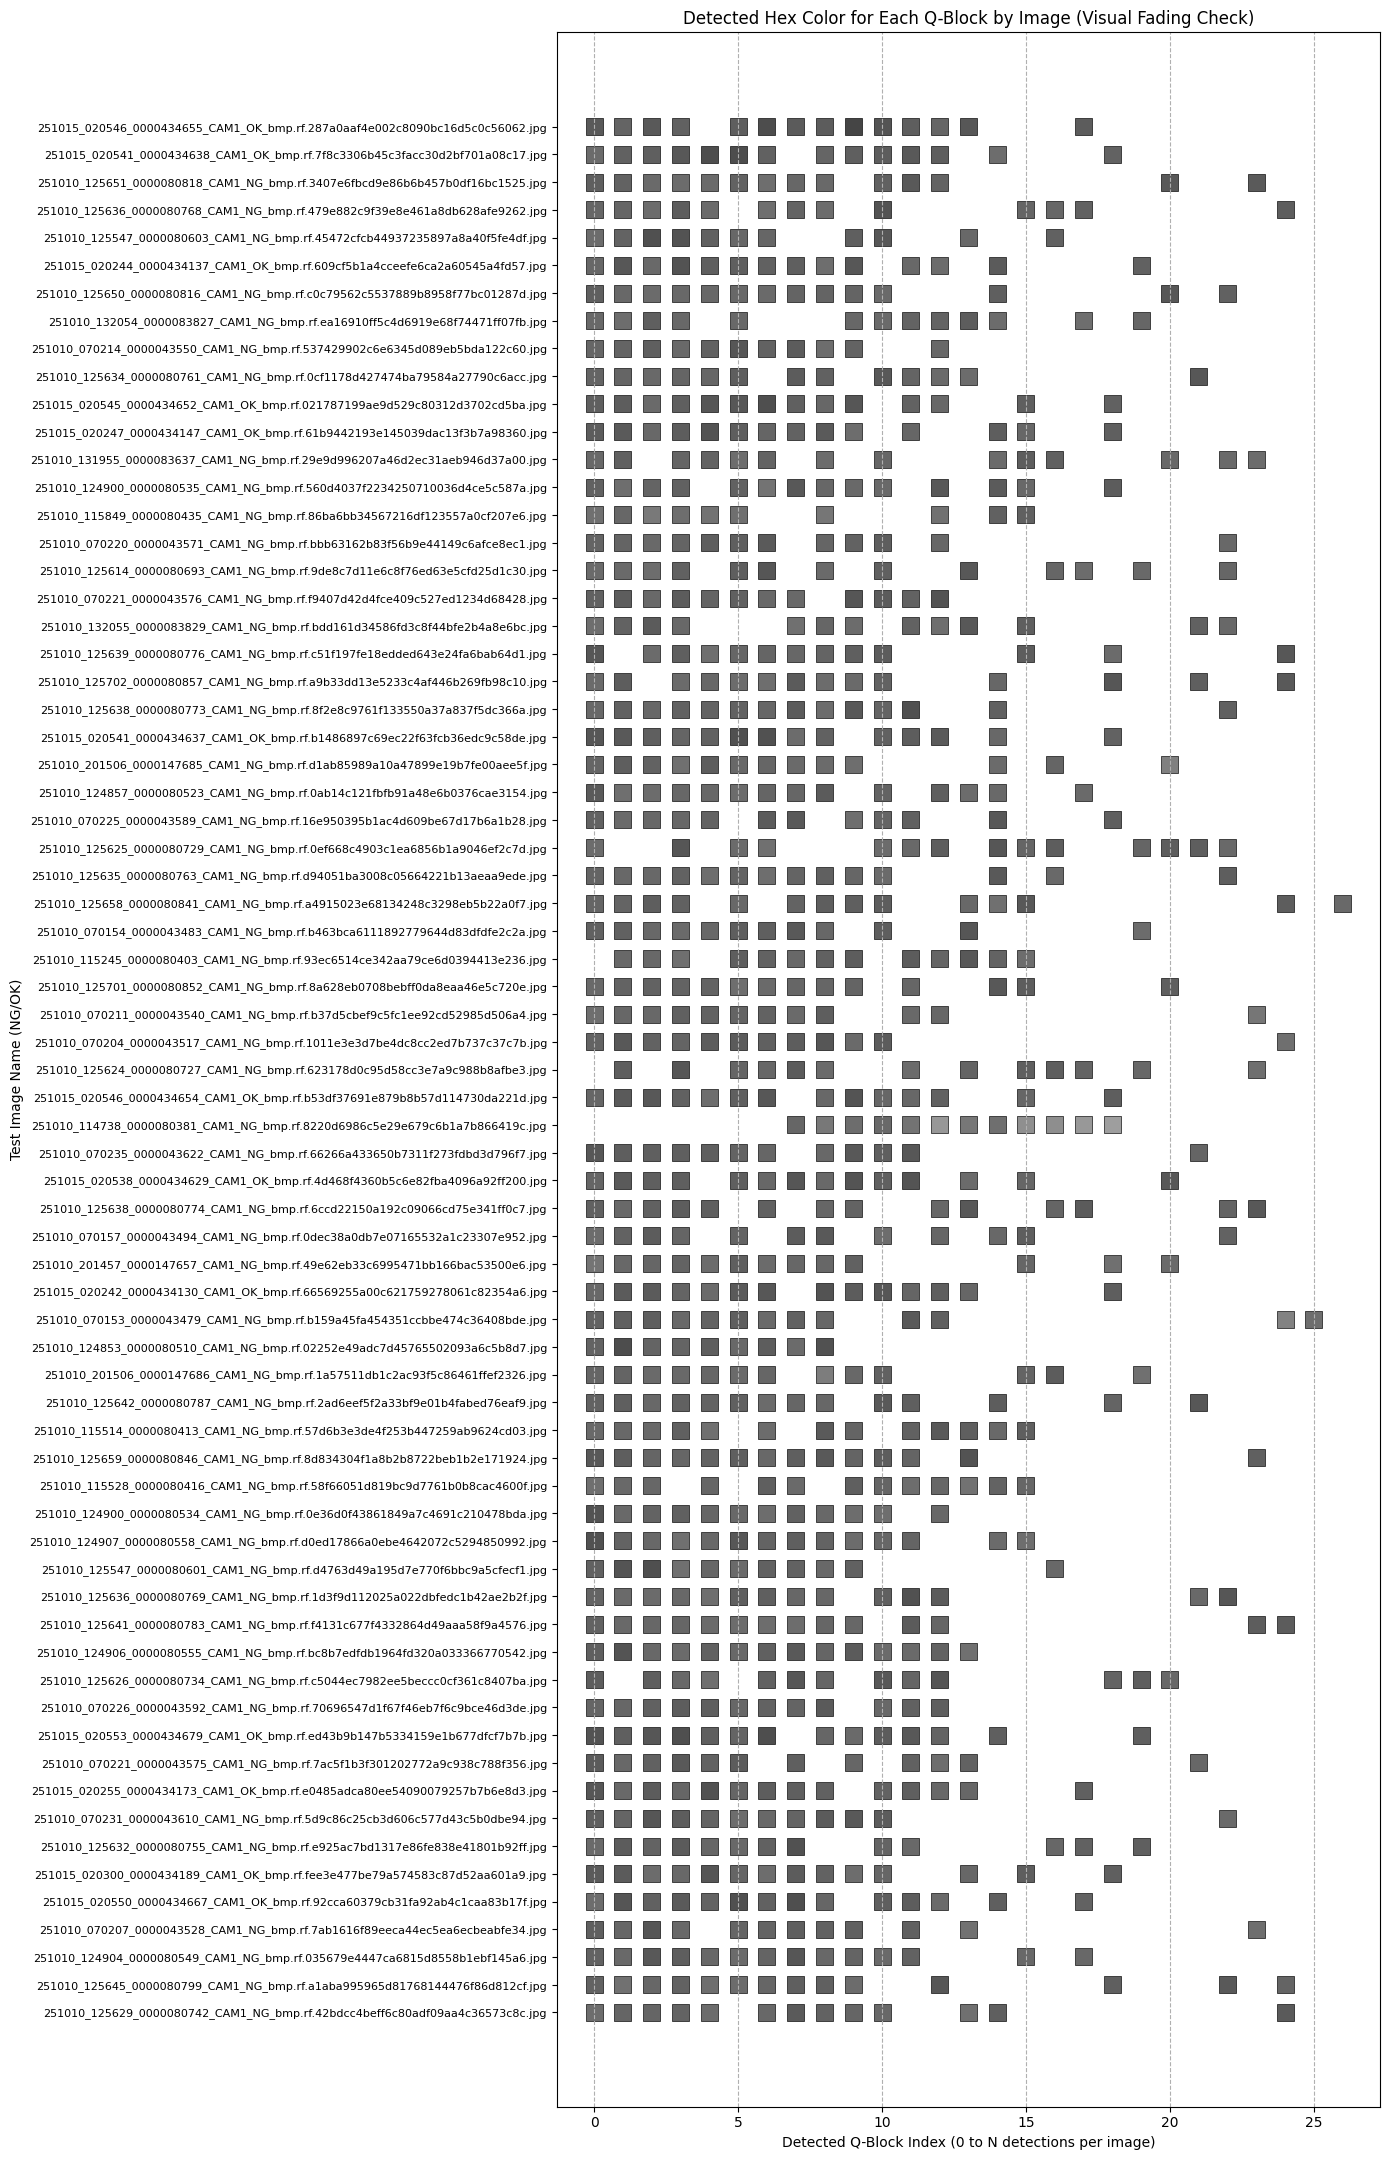

Color visualization for ALL detected blocks saved to: /content/test_results/all_qblock_color_scatter.png

--- Testing Complete! ---
Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'

--- Final QC Model Accuracy ---
Total Test Images Scored: 138
Correct Predictions:    118
QC Model Accuracy:        85.51%

--- Generating Color Visualization ---


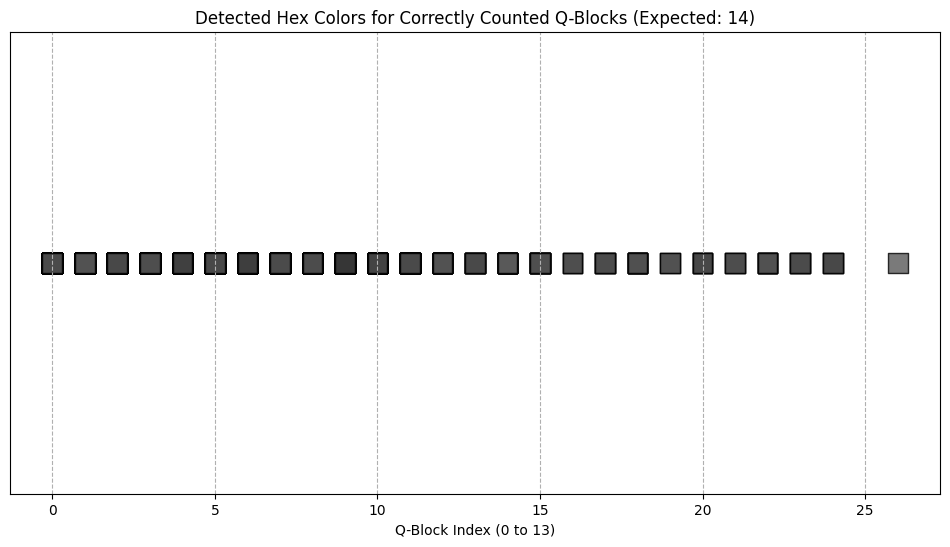

Color visualization saved to: /content/test_results/qblock_color_scatter.png

--- Generating Color Gradation Plot for Fading Check ---


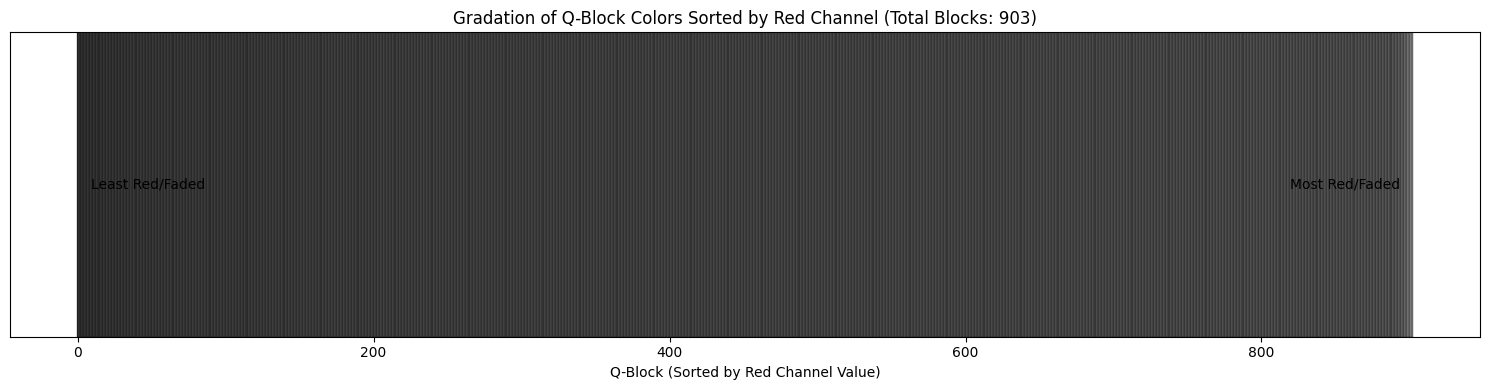

Color gradation plot saved to: /content/test_results/qblock_color_gradation.png
RGB Diagnostics plot


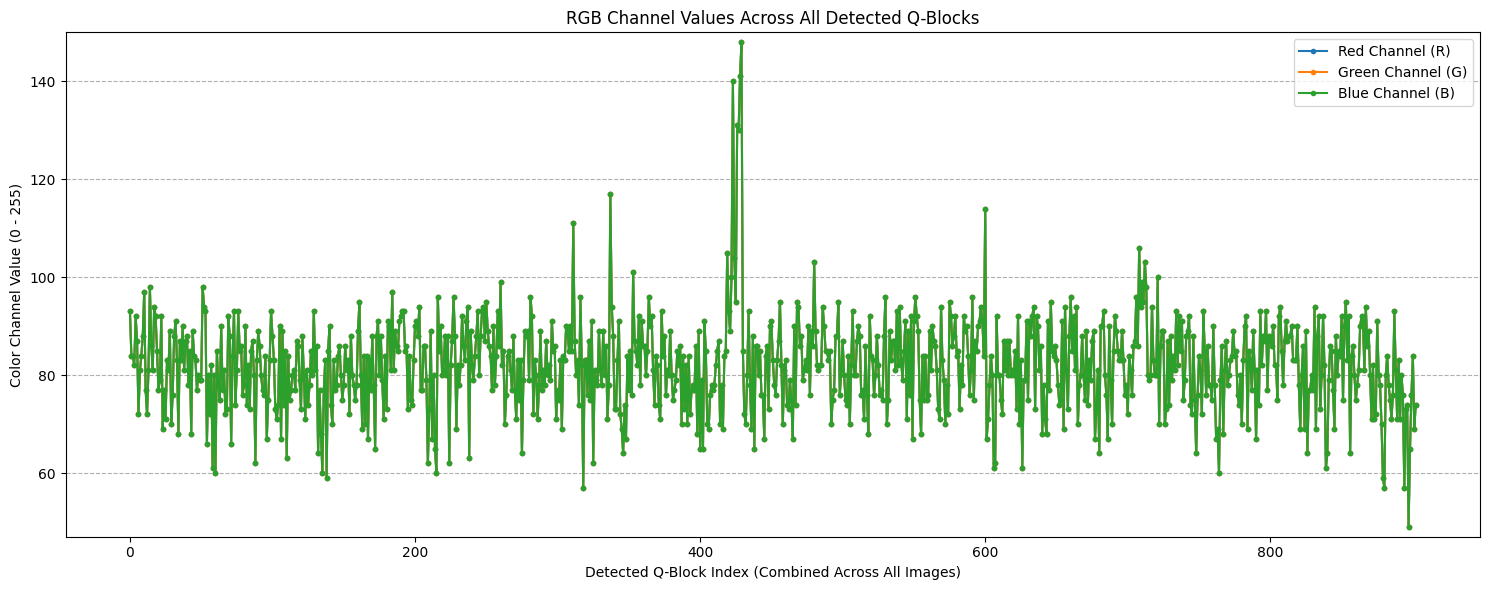

RGB diagnostic plot saved to: /content/test_results/rgb_diagnostic_plot.png


In [7]:
import os
import glob
from ultralytics import YOLO
import yaml
import matplotlib.pyplot as plt
import pandas as pd

def run_full_pipeline():
    """
    Trains, validates, and tests a YOLOv8 model. Then, it classifies
    test images based on Q-block count and calculates the
    accuracy of this classification logic against file-name-based ground truth.
    """
    # config_path = 'datasets/eagle-eyes-4/data.yaml'

    # --- Pre-run Checks ---
    if not os.path.exists(config_path):
        print(f"Error: Configuration file not found at '{config_path}'")
        return

    # --- 1. Load a Pre-trained YOLOv8 Model ---
    print("Loading pre-trained YOLOv8n model...")
    model = YOLO('yolov8n.pt')

    # --- 2. Train the Model on Your Custom Data ---
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10,
        imgsz=640,
        batch=-1,
        name='yolov8n_qblock_detector'
    )

    print("--- Training complete! ---")

    # --- 3. Display Final Validation Metrics ---
    print("\nFinal Validation Metrics from Training:")
    print(f"  mAP50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall: {results.box.mr:.4f}")

    # --- 4. Load the Best Model for Inference ---
    print("\nLoading the best model for inference...")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')
    if not os.path.exists(best_model_path):
        print(f"Error: Could not find best model at '{best_model_path}'.")
        return

    best_model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    # --- 5. Test Model and Apply Business Logic ---
    print(f"\n--- Starting Test & QC Phase ---")

    with open(config_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    if 'test' not in data_yaml or not data_yaml['test']:
        print("Warning: 'test' path not found in your YAML file. Skipping test phase.")
        return

    base_dir = os.path.dirname(os.path.abspath(config_path))

    # Use os.path.join for cross-platform compatibility (fixing the previous string concatenation)
    test_img_dir = os.path.join(base_dir, 'test', 'images')

    print(f"BASE DIRECTORY:", base_dir)
    print(f"TEST IMAGE DIRECTORY:" ,test_img_dir)

    # --- FIX: ROBUST CLASS MAPPING LOGIC ---
    names_data = data_yaml['names']

    if isinstance(names_data, dict):
        # Case 1: 'names' is a dictionary (e.g., {0: 'qblock', 1: 'smallqblock'})
        # We invert it to get {'qblock': 0}
        class_names_to_ids = {v: k for k, v in names_data.items()}
    elif isinstance(names_data, list):
        # Case 2: 'names' is a list (e.g., ['qblock', 'smallqblock', 'clutter'])
        # The index (i) is the class ID.
        class_names_to_ids = {name: i for i, name in enumerate(names_data)}
    else:
        print("Error: 'names' field in data.yaml is neither a list nor a dictionary.")
        return
    # --- END FIX ---

    # 2. Get the specific ID for the 'qblock' class
    if 'qblock' not in class_names_to_ids:
        print("Error: The class 'qblock' was not found in the dataset configuration. Check your YAML 'names' list/dict.")
        return

    QBLOCK_CLASS_ID = class_names_to_ids['qblock']
    print(f"Counting only detections with Class ID: {QBLOCK_CLASS_ID} ('qblock')")

    if not os.path.exists(test_img_dir):
        print(f"Error: Test directory specified in YAML does not exist: '{test_img_dir}'")
        return

    image_extensions = ['*.bmp', '*.jpg', '*.jpeg', '*.png']
    test_images = []
    for ext in image_extensions:
        test_images.extend(glob.glob(os.path.join(test_img_dir, ext)))

    if not test_images:
        print(f"Warning: No images found in the test directory '{test_img_dir}'. Skipping test phase.")
    else:
        print(f"Found {len(test_images)} images to test from path specified in YAML.")

        # --- QC LOGIC & ACCURACY CALCULATION ADDED HERE ---

        # 1. DEFINE YOUR "GOOD" STATE:
        EXPECTED_QBLOCK_COUNT = 14
        print(f"Applying QC Rule: Image is 'GOOD' if Q-block count is exactly {EXPECTED_QBLOCK_COUNT}.")

        # 2. Run prediction. (Code here remains the same)
        predict_results = best_model.predict(
            source=test_images,
            save=True,
            project="test_results",
            name="predictions_with_qc_accuracy",
            exist_ok=True,
            conf=0.5 # Set a confidence threshold
        )

        print("\n--- QC Classification Results ---")

        correct_predictions = 0
        total_images_processed = 0

        # 3. Loop through results and classify each image
        # for image_path, result in zip(test_images, predict_results):
        #     image_name = os.path.basename(image_path)

        #     # --- Determine Ground Truth (from filename) ---
        #     ground_truth = "UNKNOWN"
        #     if "_OK" in image_name.upper():
        #         ground_truth = "GOOD"
        #     elif "_NG" in image_name.upper():
        #         ground_truth = "NOT_GOOD"

        #     # --- MODIFIED: Determine Model Prediction (ONLY COUNT 'qblock') ---

        #     # Get the tensor of class IDs for all detected boxes
        #     class_ids = result.boxes.cls.cpu() # Move to CPU if necessary for numpy/tensor ops

        #     # Count only the instances where the class ID matches the 'qblock' ID
        #     qblock_count = (class_ids == QBLOCK_CLASS_ID).sum().item()

        #     # Use the filtered count for the QC logic
        #     num_detections = qblock_count
        #     model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

        #     # --- Score the Prediction ---
        #     if ground_truth == "UNKNOWN":
        #         print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
        #         continue

        #     total_images_processed += 1

        #     if model_prediction == ground_truth:
        #         correct_predictions += 1
        #         status = "[CORRECT]"
        #     else:
        #         status = "[INCORRECT]"

        #     print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")
        all_color_analysis = []

        for image_path, result in zip(test_images, predict_results):
            image_name = os.path.basename(image_path)

        #     # --- START NEW COLOR EXTRACTION LOGIC ---

            # Load the image using OpenCV
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not load image {image_path}")
                continue

            qblock_colors = []

            # Iterate over all detections in the image
            for box in result.boxes:
                # Check if the class is the main Q-block class
                class_id = int(box.cls.cpu().item())
                if class_id == QBLOCK_CLASS_ID:

                    # 1. Get bounding box coordinates (xyxy format: [x1, y1, x2, y2])
                    # Note: We convert to int for OpenCV slicing
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    # 2. Crop the Region of Interest (ROI)
                    roi = img[y1:y2, x1:x2]

                    # Skip if the bounding box is invalid/empty
                    if roi.size == 0:
                        continue

                    # 3. Calculate the average color (B, G, R order in OpenCV)
                    avg_color_bgr = np.mean(roi, axis=(0, 1))

                    # 4. Convert BGR to RGB and format as Hex
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    qblock_colors.append((hex_color, (r, g, b), (x1, y1, x2, y2)))



            # --- Determine Ground Truth (from filename) ---
            # ... (existing ground truth logic) ...
            ground_truth = "UNKNOWN"
            if "_OK" in image_name.upper():
                ground_truth = "GOOD"
            elif "_NG" in image_name.upper():
                ground_truth = "NOT_GOOD"

            # --- Determine Model Prediction (using the filtered count) ---
            num_detections = len(qblock_colors) # Now use the count of Q-blocks found above
            model_prediction = "GOOD" if num_detections == EXPECTED_QBLOCK_COUNT else "NOT_GOOD"

            # --- Score the Prediction ---
            if ground_truth == "UNKNOWN":
                print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: [SKIPPED]")
                continue

            total_images_processed += 1

            if model_prediction == ground_truth:
                correct_predictions += 1
                status = "[CORRECT]"
            else:
                status = "[INCORRECT]"

            print(f"Image: {image_name:<45} | GT: {ground_truth:<9} | Pred: {model_prediction:<9} ({num_detections} blocks) | Result: {status}")

            qblock_colors = []

    # Iterate over all detections in the image
            for i, box in enumerate(result.boxes): # i is the block index (0 to N)
                class_id = int(box.cls.cpu().item())

                if class_id == QBLOCK_CLASS_ID:
                    # ... (omitted: coordinate extraction) ...
                    x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].cpu().numpy()]

                    roi = img[y1:y2, x1:x2]
                    if roi.size == 0:
                        continue

                    avg_color_bgr = np.mean(roi, axis=(0, 1))
                    r, g, b = avg_color_bgr[::-1].astype(int)
                    hex_color = f'#{r:02x}{g:02x}{b:02x}'

                    # --- CAPTURE DATA IN A DICT ---
                    color_data = {
                        'image_name': image_name,
                        'block_index': i,
                        'hex_color': hex_color,
                        'r': r,
                        'g': g,
                        'b': b,
                        'ground_truth': ground_truth,
                        'model_prediction': model_prediction
                    }
                    all_color_analysis.append(color_data)

        print("\n--- Generating Color Visualization for ALL Q-Blocks ---")

        if all_color_analysis:
            # Convert the list of dictionaries to a Pandas DataFrame
            df = pd.DataFrame(all_color_analysis)

            # --- Create a single plot showing all Q-blocks and their colors ---

            # Calculate figure height dynamically based on the number of unique images
            num_images = len(df['image_name'].unique())
            fig_height = max(6, num_images * 0.3 + 1)

            plt.figure(figsize=(14, fig_height))

            # Scatter plot: X is the block index, Y is the image name, Color is the hex code
            plt.scatter(
                df['block_index'],
                df['image_name'],
                c=df['hex_color'],
                s=150, # Size of the color marker (swatch size)
                alpha=0.9,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black',
                linewidth=0.5
            )

            plt.xlabel("Detected Q-Block Index (0 to N detections per image)")
            plt.ylabel("Test Image Name (NG/OK)")
            plt.title(f"Detected Hex Color for Each Q-Block by Image (Visual Fading Check)")
            plt.grid(axis='x', linestyle='--')

            # Adjust Y-axis labels for readability if image names are long
            plt.gca().tick_params(axis='y', labelsize=8)

            # Save the visualization
            results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
            plot_path = os.path.join(results_directory, 'all_qblock_color_scatter.png')
            plt.tight_layout() # Ensures everything fits in the figure area
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization for ALL detected blocks saved to: {plot_path}")
        else:
            print("\nNo Q-blocks were detected to generate a visualization.")
                # --- END NEW COLOR EXTRACTION LOGIC ---
            # --- PRINT THE COLOR RESULTS ---
            if qblock_colors:
                print(f"    -> Detected Colors (First 3):")
                for hex_c, rgb_c, coords in qblock_colors[:3]:
                    print(f"       Box Coords: {coords} | Avg Hex Color: {hex_c}")
            elif num_detections > 0:
                 print("    -> Error: Q-blocks detected but color calculation failed.")

        print("\n--- Testing Complete! ---")
        print("Predicted test images are saved in 'test_results/predictions_with_qc_accuracy'")

        # --- 4. Calculate and Print Final Accuracy ---
        if total_images_processed > 0:
            accuracy = (correct_predictions / total_images_processed) * 100
            print("\n--- Final QC Model Accuracy ---")
            print(f"Total Test Images Scored: {total_images_processed}")
            print(f"Correct Predictions:    {correct_predictions}")
            print(f"QC Model Accuracy:        {accuracy:.2f}%")
        else:
            print("\nNo scorable images (containing '_OK' or '_NG') were found in the test set.")
    print("\n--- Generating Color Visualization ---")

    if all_color_analysis:
        df = pd.DataFrame(all_color_analysis)

        # --- Create a single plot showing all Q-blocks and their colors ---

        # Filter only images where the QC count was correct (i.e., num_detections = 14)
        # This prevents clutter from images with 0 or too many detections.
        df_correct_count = df.groupby('image_name').filter(
            lambda x: len(x) == EXPECTED_QBLOCK_COUNT
        )

        if not df_correct_count.empty:
            plt.figure(figsize=(12, 6))

            # We plot the block index vs. a constant value (0) just to place them.
            # The key information is the color and the image they belong to.
            plt.scatter(
                df_correct_count['block_index'],
                [0] * len(df_correct_count),
                c=df_correct_count['hex_color'],
                s=200, # Size of the color marker
                alpha=0.8,
                marker='s', # Use square markers for a clear color swatch
                edgecolors='black'
            )

            plt.yticks([]) # Hide the Y-axis as it's just a placeholder
            plt.xlabel("Q-Block Index (0 to 13)")
            plt.title(f"Detected Hex Colors for Correctly Counted Q-Blocks (Expected: {EXPECTED_QBLOCK_COUNT})")
            plt.grid(axis='x', linestyle='--')

            # Optional: Add the average hex color for all blocks in the image
            # avg_color = df_correct_count.groupby('image_name')[['r', 'g', 'b']].mean().apply(
            #     lambda x: f'#{int(x.r):02x}{int(x.g):02x}{int(x.b):02x}', axis=1
            # )

            # Save the visualization
            plot_path = os.path.join(results_directory, 'qblock_color_scatter.png')
            plt.savefig(plot_path)
            plt.show()
            print(f"Color visualization saved to: {plot_path}")
        else:
            print("No images found with the exact expected Q-block count (14) to generate a visualization.")
    print("\n--- Generating Color Gradation Plot for Fading Check ---")

    if all_color_analysis:
        df_all = pd.DataFrame(all_color_analysis)

        # Calculate the average color component to sort by.
        # Using 'r' is common, as fading often results in a higher R or overall brightness.
        # You could also use 'b' (if the blocks are blue) or 'r+g+b' for overall brightness.

        # Sort the entire dataset by the Red component (ascending = least red to most red/faded)
        df_sorted = df_all.sort_values(by='r', ascending=True).reset_index(drop=True)

        plt.figure(figsize=(15, 4))

        # Create a bar plot using the hex color for the bar color
        plt.bar(
            x=df_sorted.index,
            height=1, # Constant height for visibility
            color=df_sorted['hex_color'],
            width=1, # Width of 1 to create solid adjacent bars
            edgecolor='black',
            linewidth=0.2
        )

        plt.title(f"Gradation of Q-Block Colors Sorted by Red Channel (Total Blocks: {len(df_sorted)})")
        plt.xlabel("Q-Block (Sorted by Red Channel Value)")

        # Remove y-axis ticks and labels as they are meaningless here
        plt.yticks([])

        # Set y-limits to just show the bar
        plt.ylim(0, 1)

        # Add a note on the plot to identify the direction of fading
        plt.text(len(df_sorted) * 0.01, 0.5, 'Least Red/Faded',
                verticalalignment='center', color='black', fontsize=10)
        plt.text(len(df_sorted) * 0.99, 0.5, 'Most Red/Faded',
                verticalalignment='center', color='black', fontsize=10, ha='right')

        # Save and display the plot
        results_directory = os.path.dirname(os.path.abspath(predict_results[0].save_dir))
        gradation_path = os.path.join(results_directory, 'qblock_color_gradation.png')
        plt.tight_layout()
        plt.savefig(gradation_path)
        plt.show() # Display the plot in the notebook

        print(f"Color gradation plot saved to: {gradation_path}")

    else:
        print("\nNo Q-blocks were detected to generate a gradation plot.")

  # print("Color gradation plot")
  # plot_color_gradation(all_color_analysis, results_directory)
    print("RGB Diagnostics plot")
    plot_rgb_diagnostic(all_color_analysis, results_directory)

# You would call this function after the prediction loop completes
# plot_color_gradation(all_color_analysis, results_directory)
if __name__ == '__main__':
    run_full_pipeline()
